# EDA - Exploratory Data Analysis
## Objetives

- Validate the data quality
- Make some initial visualizations
- Study the distributions of the variables
- Look for correlations between variables
- Identify potential features for modeling
- Generate a report dataset that contains the features identified and the target variables

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib as pl
from scipy.interpolate import interp1d
import seaborn as sns
import numpy as np

## Constants

In [2]:
data_path = pl.Path("D:/Data/frusan/cleanest")

In [3]:
# Maestros data
maestro_entidades_path       = data_path / "maestro_entidades_unicas.csv"
maestro_tratamientos_path    = data_path / "maestro_tratamientos.csv"
maestro_variedades_path      = data_path / "maestro_variedades.csv"
maestros_zonas_path          = data_path / "maestro_zonas.csv"

# In Latency data
in_almidon_path              = data_path / "entrada_almidon_en_yemas_with_entity_id.csv"
in_caida_hojas_path          = data_path / "entrada_caida_hojas_with_entity_id.csv"
in_materia_seca_path         = data_path / "entrada_materia_seca_with_entity_id.csv"

# Out Latency data
out_almidon_path             = data_path / "salida_almidon_en_yemas_with_entity_id.csv"
out_brotacion_campo_path     = data_path / "salida_brotacion_en_campo_with_entity_id.csv"
out_cuaja_path               = data_path / "salida_cuaja_with_entity_id.csv"
out_materia_seca_path        = data_path / "salida_materia_seca_with_entity_id.csv"

# Temperature zones
temp_zone_1_path             = data_path / "temp_zone=1.csv"
temp_zone_2_path             = data_path / "temp_zone=2.csv"
temp_zone_3_path             = data_path / "temp_zone=3.csv"
temp_zone_4_path             = data_path / "temp_zone=4.csv"
temp_zone_5_path             = data_path / "temp_zone=5.csv"
temp_zone_6_path             = data_path / "temp_zone=6.csv"
temp_zone_7_path             = data_path / "temp_zone=7.csv"
temp_zone_8_path             = data_path / "temp_zone=8.csv"
temp_zone_9_path             = data_path / "temp_zone=9.csv"

## Data Loading

In [4]:
maestro_entidades = pd.read_csv(maestro_entidades_path)
maestro_tratamientos = pd.read_csv(maestro_tratamientos_path)
maestro_variedades = pd.read_csv(maestro_variedades_path)
maestros_zonas = pd.read_csv(maestros_zonas_path)

In [5]:
in_almidon = pd.read_csv(in_almidon_path)
in_caida_hojas = pd.read_csv(in_caida_hojas_path)
in_materia_seca = pd.read_csv(in_materia_seca_path)

In [6]:
out_almidon = pd.read_csv(out_almidon_path)
out_brotacion_campo = pd.read_csv(out_brotacion_campo_path)
out_cuaja = pd.read_csv(out_cuaja_path)
out_materia_seca = pd.read_csv(out_materia_seca_path)

## Exploracion maestros

In [7]:
# Maestro zonas contiene la informacion de las zonas donde se estudia el cultivo
print("Maestro Zonas Shape:", maestros_zonas.shape)
maestros_zonas.head()

Maestro Zonas Shape: (9, 2)


,zona_id,zona
0,0,melipilla
1,1,viluco
2,2,pichidegua
3,3,teno prado
4,4,santa ana


In [8]:
# Maestro variedades contiene la informacion de las variedades de frutales
print("Maestro Variedades Shape:", maestro_variedades.shape)
maestro_variedades.head()

Maestro Variedades Shape: (3, 2)


,variedad_id,variedad
0,0,regina
1,1,santina
2,2,kordia


In [9]:
# Maestro tratamientos contiene la informacion de los tratamientos aplicados tanto en entrada como en salida
print("Maestro Tratamientos Shape:", maestro_tratamientos.shape)
print("Tratamientos de Entrada:")
maestro_tratamientos_entrada = maestro_tratamientos[maestro_tratamientos['tipo'] == 'entrada']
print(maestro_tratamientos_entrada.shape)
maestro_tratamientos_entrada.head()
print("Tratamientos de Salida:")
maestro_tratamientos_salida = maestro_tratamientos[maestro_tratamientos['tipo'] == 'salida']
print(maestro_tratamientos_salida.shape)

Maestro Tratamientos Shape: (17, 3)
Tratamientos de Entrada:
(7, 3)
Tratamientos de Salida:
(10, 3)


In [10]:
# Finalmente se crea el concepto de una entidad como un "arbol" o una unidad experimental para poder conectar facilmente los datos de entrada y salida
print("Maestro Entidades Shape:", maestro_entidades.shape)
maestro_entidades.head()

Maestro Entidades Shape: (420, 10)


,entidad_id,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue
0,0,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1
1,1,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2
2,2,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3
3,3,2,pichidegua,1,santina,3,zn+u+eth,6,control,4
4,4,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5


In [11]:
# Tambien al usar los id de tratamiento y variedad se puede consultar rapidamente la informacion de los mismos
# Aqui veamos la cantidad de entidades que recibieron el tratamiento de entrada "0" (Control) y el tratamiento de salida "6" (Control)
maestro_entidades_subset = maestro_entidades.loc[
    (maestro_entidades['tratamiento_entrada_id'] == 0) &
    (maestro_entidades['tratamiento_salida_id'] == 6)
]
print("Cantidad de entidades con tratamiento de entrada '0' y tratamiento de salida '6':", maestro_entidades_subset.shape[0])
maestro_entidades_subset.head()

Cantidad de entidades con tratamiento de entrada '0' y tratamiento de salida '6': 28


,entidad_id,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue
7,7,2,pichidegua,1,santina,0,control,6,control,8
15,15,2,pichidegua,1,santina,0,control,6,control,16
37,37,3,teno prado,1,santina,0,control,6,control,8
45,45,3,teno prado,1,santina,0,control,6,control,16
67,67,0,melipilla,1,santina,0,control,6,control,8


In [12]:
# Imprimamos el resumen estadistico de las entidades (Cuantas entidades por zona, variedad, tratamiento, etc)
# Hay combinaciones que no tienen entidades asociadas y eso es importante tenerlo en cuenta
maestro_entidades_summary = maestro_entidades.groupby(
    ['zona', 'variedad', 'tratamiento_entrada', 'tratamiento_salida']
).size()
print("Resumen estadistico de las entidades (Cantidad de entidades por zona, variedad, tratamiento de entrada y tratamiento de salida):")
maestro_entidades_summary

Resumen estadistico de las entidades (Cantidad de entidades por zona, variedad, tratamiento de entrada y tratamiento de salida):


zona       variedad  tratamiento_entrada  tratamiento_salida          
melipilla  santina   aba                  control                         1
                                          dormex 3% + break               1
                                          erger 5% + nca 6%               1
                     control              control                         2
                                          erger 5% + nca 6%               1
                                                                         ..
wapri      regina    zn+eth               dormex 1,5% + 2% ac. mineral    1
                                          dormex 2% + break               1
                                          erger 5% + nca 4%               1
                     zn+u+eth             control                         1
                                          dormex 1,5% + 2% ac. mineral    2
Length: 210, dtype: int64

## Exploracion datos de entrada

### Entrada Almidon en Yemas

In [13]:
# Primero revisemos que porcentaje de las entidades tiene datos de entrada de almidon en yemas
entidades_unicas = maestro_entidades['entidad_id'].unique().tolist()
entidades_con_almidon = in_almidon['entidad_id'].unique().tolist()
entidades_sin_almidon = list(set(entidades_unicas) - set(entidades_con_almidon))
porcentaje_con_almidon = (len(entidades_con_almidon) / len(entidades_unicas)) * 100
porcentaje_sin_almidon = (len(entidades_sin_almidon) / len(entidades_unicas)) * 100
print(f"Porcentaje de entidades con datos de entrada de almidon en yemas: {porcentaje_con_almidon:.2f}%")
print(f"Porcentaje de entidades sin datos de entrada de almidon en yemas: {porcentaje_sin_almidon:.2f}%")

Porcentaje de entidades con datos de entrada de almidon en yemas: 51.43%
Porcentaje de entidades sin datos de entrada de almidon en yemas: 48.57%


In [14]:
# Veamos las entidades que no tienen datos de almidon en yemas
maestro_entidades.loc[maestro_entidades['entidad_id'].isin(entidades_sin_almidon)].head()

,entidad_id,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue
0,0,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1
1,1,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2
2,2,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3
3,3,2,pichidegua,1,santina,3,zn+u+eth,6,control,4
4,4,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5


In [15]:
# Unamos los datos de entrada de almidon con el maestro de entidades para ver la informacion completa
# Si falla pq no encuentra la entidad_id, levantar error
in_almidon_merged = in_almidon.merge(maestro_entidades, on='entidad_id', how='left', validate='many_to_one', indicator=True)

if (in_almidon_merged['_merge'] != 'both').sum() > 0:
    print("Fallaron uniones (deberia ser 0):", (in_almidon_merged['_merge'] != 'both').sum())
    raise ValueError("Fallo la union entre in_almidon y maestro_entidades")

print("Datos de entrada de almidon en yemas unidos con maestro de entidades:")
in_almidon_merged.head()

Datos de entrada de almidon en yemas unidos con maestro de entidades:


,entidad_id,fecha,muestreo,peso_yema_mg,absorbancia,concentracion_almidon_mg_por_g,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
0,6,2024-04-19,M1,200.3,0.9595,20.475879,2,pichidegua,1,santina,3,zn+u+eth,8,dormex 2% + 2% ac. mineral,7,both
1,7,2024-04-19,M1,200.2,1.0239,21.974325,2,pichidegua,1,santina,0,control,6,control,8,both
2,8,2024-04-19,M1,201.4,1.1227,24.112958,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,9,both
3,9,2024-04-19,M1,201.3,0.7210,14.892787,2,pichidegua,1,santina,5,aba,6,control,10,both
4,10,2024-04-19,M1,201.0,1.0012,21.364379,2,pichidegua,1,santina,2,zn+eth,11,erger 5% + nca 6%,11,both


In [16]:
in_almidon.describe()

,entidad_id,peso_yema_mg,absorbancia,concentracion_almidon_mg_por_g
count,432.000000,430.000000,430.000000,430.000000
mean,218.666667,200.484419,0.967238,20.635041
std,129.261619,0.349711,0.209950,4.841806
min,6.000000,200.000000,0.349600,6.391943
25%,94.250000,200.200000,0.861850,18.224960
50%,227.500000,200.500000,0.995350,21.305254
75%,330.750000,200.700000,1.092975,23.566071
max,419.000000,202.200000,1.751300,38.667905


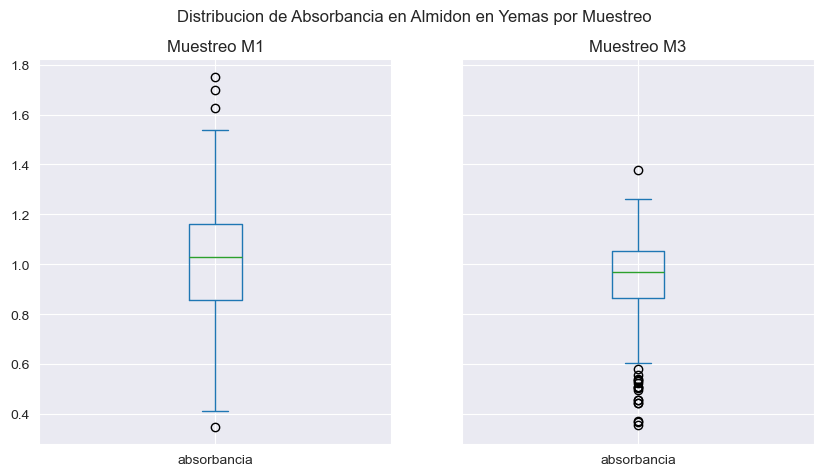

In [17]:
# Grafiquemos los valores de absorbancia por cada muestreo
# Creamos un subplot de 1xNmuestros donde Nmuestreos es la cantidad de muestreos unicos en el dataset
n_muestreos = in_almidon_merged['muestreo'].nunique()
fig, axes = plt.subplots(1, n_muestreos, figsize=(5*n_muestreos, 5), sharey=True)

for i, muestreo in enumerate(in_almidon_merged['muestreo'].unique()):
    data_muestreo = in_almidon_merged[in_almidon_merged['muestreo'] == muestreo]
    axes[i] = data_muestreo['absorbancia'].plot(kind='box', ax=axes[i], title=f'Muestreo {muestreo}')
plt.suptitle('Distribucion de Absorbancia en Almidon en Yemas por Muestreo')
plt.show()


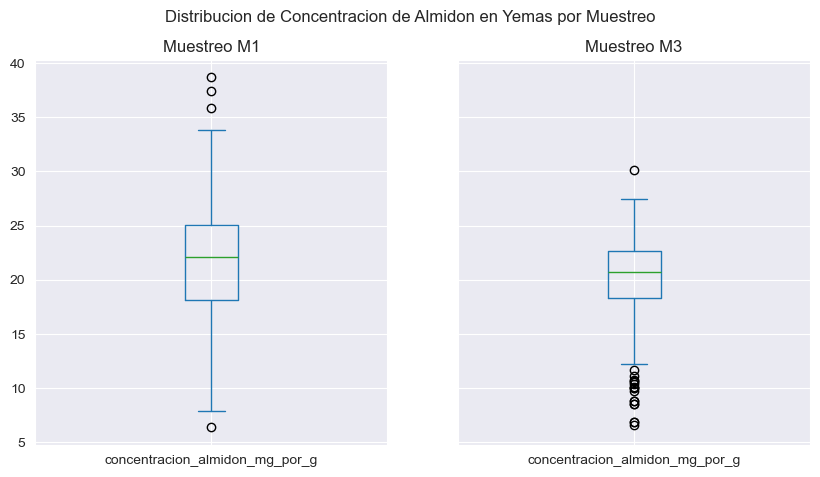

In [18]:
# Lo mismo pero para concentracion_almidon_mg_por_g
fig, axes = plt.subplots(1, n_muestreos, figsize=(5*n_muestreos, 5), sharey=True)
for i, muestreo in enumerate(in_almidon_merged['muestreo'].unique()):
    data_muestreo = in_almidon_merged[in_almidon_merged['muestreo'] == muestreo]
    axes[i] = data_muestreo['concentracion_almidon_mg_por_g'].plot(kind='box', ax=axes[i], title=f'Muestreo {muestreo}')
plt.suptitle('Distribucion de Concentracion de Almidon en Yemas por Muestreo')
plt.show()

In [19]:
# Veamos en que fechas consideran cada muestreo
in_almidon_merged.groupby('muestreo')['fecha'].unique()


muestreo
M1    [2024-04-19, 2024-04-22, 2024-04-23, 2024-04-2...
M3     [2024-05-31, 2024-06-10, 2024-05-30, 2024-06-05]
Name: fecha, dtype: object

#### Resumen
- Se tienen 2 caracteristicas principales en los datos de entrada de almidon en yemas: absorbancia y concentracion_almidon_mg_por_g.
- Ambas variables muestran variabilidad entre los diferentes muestreos. Los muestreos no se toman en exactamente las mismas fechas, lo que puede influir en los resultados. Pero se usan para agrupar las mediciones.
- Un porcentaje significativo de entidades no tiene datos de almidon en yemas.
- Absorbancia: Valor de absorbancia de luz de la muestra obtenido mediante espectrofotometría. Medida adimensional, normalmente fluctúa entre 0 y 1.
- Concentracion almidon mg por g: Concentración de almidón en la muestra expresado en milígramos de azúcares en gramos de muestra (mg/g). Normalmente fluctúa entre 20 y 30 mg/g, en base a análisis anteriores para muestras del mismo origen (yemas reproductivas de cerezos).

-- Conclusion pre-eliminar: Ambas variables pueden ser utiles pero me preocupa la cantidad de datos faltantes en muchas entidades. Habrá que ver si se pueden imputar de alguna forma.


### Entrada Caida de Hojas

In [20]:
# Veamos el porcentaje de entidades que tienen datos de caida de hojas
# Deberia si o si estar entero ya que se definieron las entidades en base a estos datos
entidades_con_caida_hojas = in_caida_hojas['entidad_id'].unique().tolist()
entidades_sin_caida_hojas = list(set(entidades_unicas) - set(entidades_con_caida_hojas))
porcentaje_con_caida_hojas = (len(entidades_con_caida_hojas) / len(entidades_unicas)) * 100
porcentaje_sin_caida_hojas = (len(entidades_sin_caida_hojas) / len(entidades_unicas)) * 100
print(f"Porcentaje de entidades con datos de entrada de caida de hojas: {porcentaje_con_caida_hojas:.2f}%")
print(f"Porcentaje de entidades sin datos de entrada de caida de hojas: {porcentaje_sin_caida_hojas:.2f}%")

Porcentaje de entidades con datos de entrada de caida de hojas: 100.00%
Porcentaje de entidades sin datos de entrada de caida de hojas: 0.00%


In [21]:
# Combinemos con el maestro de entidades para tener toda la informacion
in_caida_hojas_merged = in_caida_hojas.merge(maestro_entidades, on='entidad_id', how='left', validate='many_to_one', indicator=True)
if (in_caida_hojas_merged['_merge'] != 'both').sum() > 0:
    print("Fallaron uniones (deberia ser 0):", (in_caida_hojas_merged['_merge'] != 'both').sum())
    raise ValueError("Fallo la union entre in_caida_hojas y maestro_entidades")
print("Datos de entrada de caida de hojas unidos con maestro de entidades:")
in_caida_hojas_merged.head()

Datos de entrada de caida de hojas unidos con maestro de entidades:


,entidad_id,fecha,porcentaje_amarilla,porcentaje_verde_amarilla,porcentaje_verde,porcentaje_hojas_caidas,porcentaje_danio,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
0,0,2024-04-19,5,5,85,5,0,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1,both
1,1,2024-04-19,8,5,84,3,0,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2,both
2,2,2024-04-19,3,1,94,2,0,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3,both
3,3,2024-04-19,15,5,75,5,0,2,pichidegua,1,santina,3,zn+u+eth,6,control,4,both
4,4,2024-04-19,10,3,85,2,0,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5,both


Text(0.5, 0, 'Fecha')

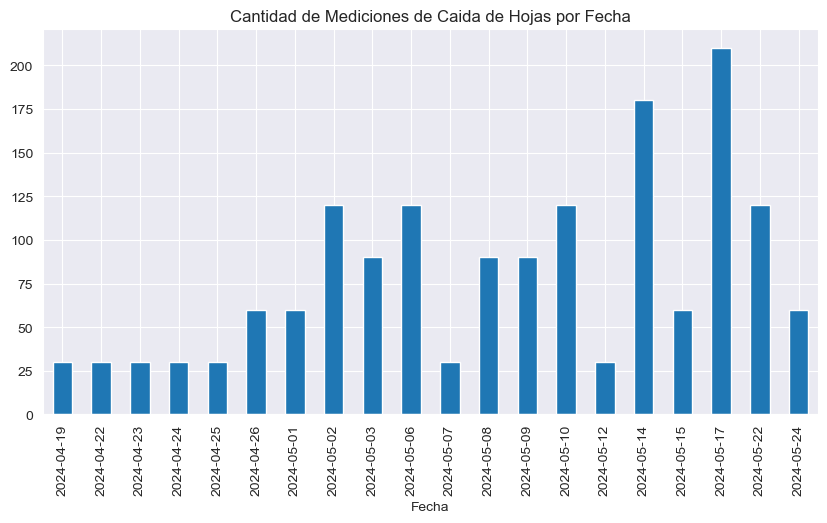

In [22]:
# Veamos la dispersión de las fechas
mediciones_por_fecha = in_caida_hojas_merged.groupby('fecha').size()
mediciones_por_fecha.plot(kind='bar', title='Cantidad de Mediciones de Caida de Hojas por Fecha', figsize=(10,5))
plt.xlabel('Fecha')

Text(0, 0.5, 'Cantidad de Entidades')

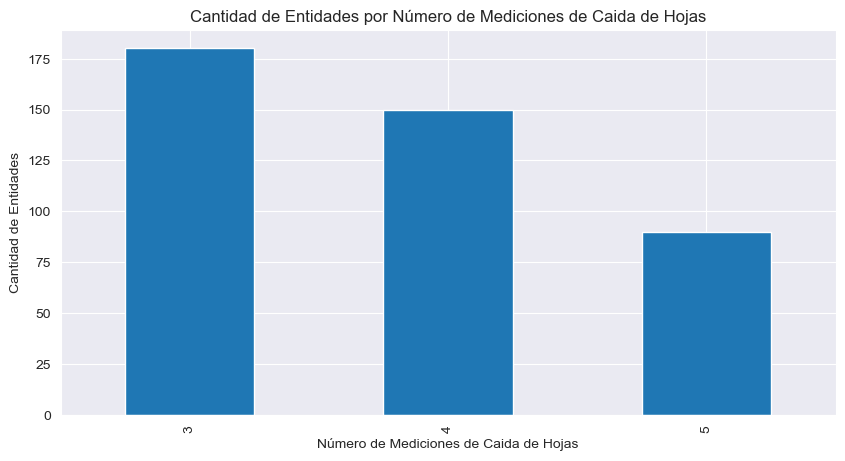

In [23]:
# Y veamos las mediciones por entidad
# Cada entidad tiene varias mediciones a lo largo del tiempo
mediciones_por_entidad = in_caida_hojas_merged.groupby('entidad_id').size()
# Veamoslo al reves, cuantas entidades tienen N mediciones
entidades_por_numero_de_mediciones = mediciones_por_entidad.value_counts().sort_index()
entidades_por_numero_de_mediciones.plot(kind='bar', title='Cantidad de Entidades por Número de Mediciones de Caida de Hojas', figsize=(10,5))
plt.xlabel('Número de Mediciones de Caida de Hojas')
plt.ylabel('Cantidad de Entidades')

Text(0, 0.5, 'Caida de Hojas (%)')

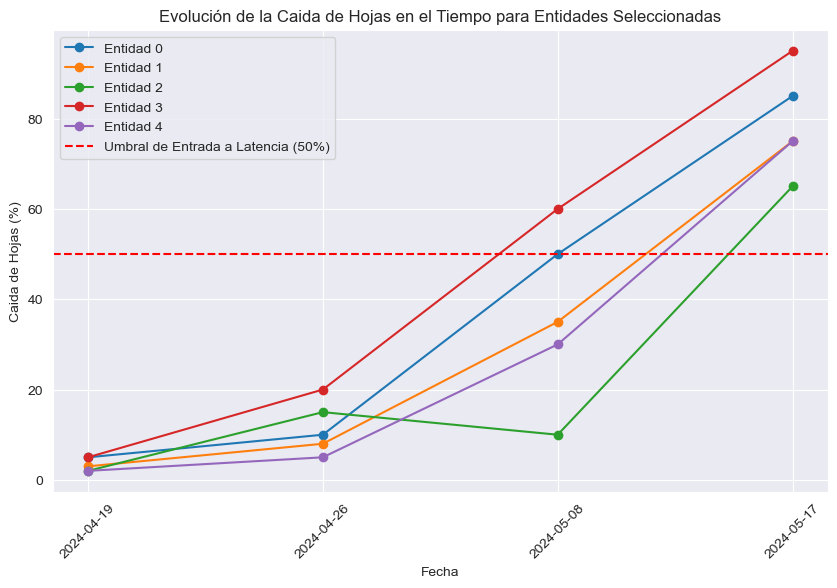

In [24]:
# Este dato es importante porque nuestro criterio de entrada a latencia es la caida de hojas
# Hagamos un grafico de lineas para ver la evolucion de la caida de hojas en el tiempo para algunas entidades seleccionadas
sampled_entities = in_caida_hojas_merged['entidad_id'].unique()[:5]  # Tomemos las primeras 5 entidades como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = in_caida_hojas_merged[in_caida_hojas_merged['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='fecha')
    plt.plot(data_entidad['fecha'], data_entidad['porcentaje_hojas_caidas'], marker='o', label=f'Entidad {entidad}')
    # Tilt the x-axis labels for better readability
    plt.xticks(rotation=45)
    # Add legend

# Dibujemos una linea horizontal en y=50 para marcar el umbral de entrada a latencia
plt.axhline(y=50, color='r', linestyle='--', label='Umbral de Entrada a Latencia (50%)')
plt.legend()
plt.title('Evolución de la Caida de Hojas en el Tiempo para Entidades Seleccionadas')
plt.xlabel('Fecha')
plt.ylabel('Caida de Hojas (%)')

In [25]:
# Se puede ver que la caida de hojas aumenta con el tiempo y es relativamente lineal
# Vamos a interpolar linealmente esta serie temporal para estimar la fecha exacta en que cada entidad cruzo el umbral del 50%
def interpolar_y_fecha_50(group):
    g = group.sort_values("fecha").copy()
    g['fecha'] = pd.to_datetime(g['fecha'])

    # conservar columnas necesarias y quitar filas sin porcentaje
    g = g[['entidad_id', 'fecha', 'porcentaje_hojas_caidas']].dropna(subset=['porcentaje_hojas_caidas'])
    if g.empty:
        return pd.DataFrame(columns=['entidad_id', 'fecha', 'porcentaje_interp'])

    # convertir fechas a número de días desde la mínima fecha
    t = (g['fecha'] - g['fecha'].min()).dt.total_seconds() / 86400.0
    y = g['porcentaje_hojas_caidas'].values

    # si solo hay un punto no se puede estimar pendiente -> devolver ese punto
    if len(y) == 1:
        return pd.DataFrame({
            'entidad_id': [g['entidad_id'].iloc[0]],
            'fecha': [g['fecha'].iloc[0]],
            'porcentaje_interp': [y[0]]
        })

    # interpolador con extrapolación permitida
    f = interp1d(t, y, kind='linear', fill_value='extrapolate', assume_sorted=True)

    # pendiente del último par de puntos
    t_vals = t.values
    slope = (y[-1] - y[-2]) / (t_vals[-1] - t_vals[-2]) if (t_vals[-1] - t_vals[-2]) != 0 else 0.0

    # determinar hasta dónde generar la grilla (en días)
    y_last = y[-1]
    if y_last >= 100:
        # ya alcanzó 100 en los datos: buscar primer cruce en la malla interna
        t_dense = np.arange(t_vals.min(), t_vals[-1] + 1e-6, 0.1)
        y_dense = f(t_dense)
        cruzamientos = np.where(y_dense >= 100)[0]
        if len(cruzamientos) > 0:
            t_end = t_dense[cruzamientos[0]]
        else:
            t_end = t_vals[-1]
    else:
        if slope > 0:
            # días necesarios para llegar a 100 usando la pendiente del último tramo
            days_needed = (100.0 - y_last) / slope
            t_end = t_vals[-1] + max(days_needed, 0.0)
        else:
            # no se puede alcanzar 100 con pendiente no positiva -> quedar en el último día
            t_end = t_vals[-1]

    # generar grilla diaria desde el mínimo hasta t_end
    t_new = np.arange(t_vals.min(), t_end + 1e-6, 1.0)
    y_new = f(t_new)

    # limitar a 100 como máximo y a 0 como mínimo por seguridad
    y_new = np.clip(y_new, 0.0, 100.0)

    serie_item = pd.DataFrame({
        'entidad_id': g['entidad_id'].iloc[0],
        'fecha': g['fecha'].min() + pd.to_timedelta(t_new, unit='D'),
        'porcentaje_interp': y_new
    })

    return serie_item

def find_fecha_50(serie):
    # Buscar el primer índice donde el valor interpolado cruza el 50%
    cruzamiento_indices = np.where(serie['porcentaje_interp'] >= 50)[0]
    if len(cruzamiento_indices) == 0:
        return None  # No cruzó el umbral
    indice_cruce = cruzamiento_indices[0]
    return serie['fecha'].iloc[indice_cruce]


In [26]:
test_group = in_caida_hojas_merged[in_caida_hojas_merged['entidad_id'] == 0][['entidad_id', 'fecha','porcentaje_hojas_caidas']]
serie_item = interpolar_y_fecha_50(test_group)
fecha_50   = find_fecha_50(serie_item)
print("Fecha estimada de cruce del umbral del 50% de caida de hojas para la entidad 0:", fecha_50)

print("Serie densa generada:")
print(serie_item)


Fecha estimada de cruce del umbral del 50% de caida de hojas para la entidad 0: 2024-05-08 00:00:00
Serie densa generada:
    entidad_id      fecha  porcentaje_interp
0            0 2024-04-19           5.000000
1            0 2024-04-20           5.714286
2            0 2024-04-21           6.428571
3            0 2024-04-22           7.142857
4            0 2024-04-23           7.857143
5            0 2024-04-24           8.571429
6            0 2024-04-25           9.285714
7            0 2024-04-26          10.000000
8            0 2024-04-27          13.333333
9            0 2024-04-28          16.666667
10           0 2024-04-29          20.000000
11           0 2024-04-30          23.333333
12           0 2024-05-01          26.666667
13           0 2024-05-02          30.000000
14           0 2024-05-03          33.333333
15           0 2024-05-04          36.666667
16           0 2024-05-05          40.000000
17           0 2024-05-06          43.333333
18           0 2024-05-

In [27]:
# Ahora apliquemos esta función a todas las entidades
result_list = []
serie_densa_list = []

for entidad_id, group in in_caida_hojas_merged.groupby('entidad_id'):
    serie_item = interpolar_y_fecha_50(group[['entidad_id', 'fecha','porcentaje_hojas_caidas']])
    serie_densa_list.append(serie_item)

    fecha_50  = find_fecha_50(serie_item)
    result_list.append({
        'entidad_id': entidad_id,
        'fecha_50': fecha_50
    })



# Concatenar todos los resultados
fecha_50_df = pd.DataFrame(result_list)
serie_densa_df = pd.concat(serie_densa_list, ignore_index=True)
print("Fechas estimadas de cruce del umbral del 50% de caida de hojas:")
fecha_50_df

Fechas estimadas de cruce del umbral del 50% de caida de hojas:


,entidad_id,fecha_50
0,0,2024-05-08
1,1,2024-05-12
2,2,2024-05-15
3,3,2024-05-05
4,4,2024-05-12
...,...,...
415,415,2024-05-10
416,416,2024-05-16
417,417,2024-05-12
418,418,2024-05-10


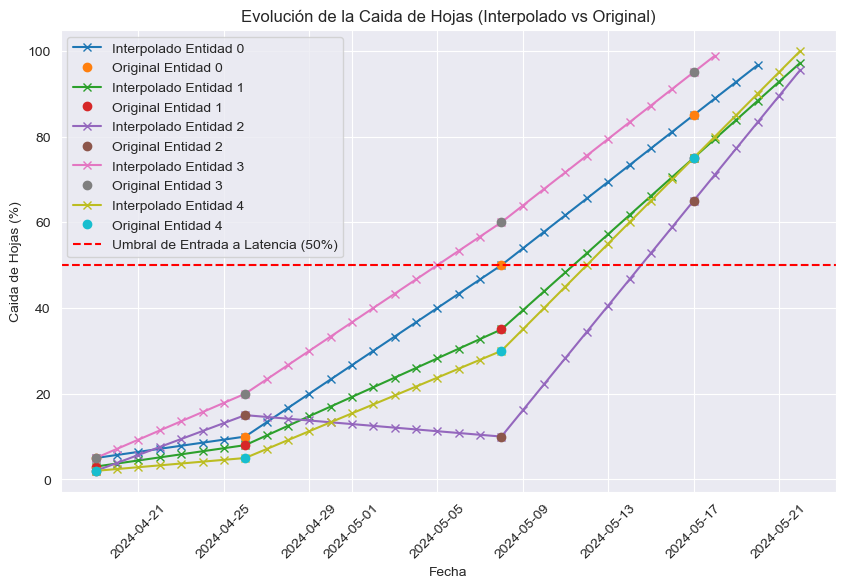

In [28]:
# Ploteemos algunas series densas para verificar visualmente
# Tomemos las primeras 5 entidades como muestra y marquemos los puntos originales de un color y los interpolados de otro
sampled_entities = in_caida_hojas_merged['entidad_id'].unique()[:5]  # Tomemos las primeras 5 entidades como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = in_caida_hojas_merged[in_caida_hojas_merged['entidad_id'] == entidad]
    data_serie = serie_densa_df[serie_densa_df['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='fecha')
    data_serie = data_serie.sort_values(by='fecha')
    data_entidad['fecha'] = pd.to_datetime(data_entidad['fecha'])

    plt.plot(data_serie['fecha'], data_serie['porcentaje_interp'], '-x', label=f'Interpolado Entidad {entidad}')
    plt.plot(data_entidad['fecha'], data_entidad['porcentaje_hojas_caidas'], 'o', label=f'Original Entidad {entidad}')

    # Tilt the x-axis labels for better readability
    plt.xticks(rotation=45)
# Add legend
plt.axhline(y=50, color='r', linestyle='--', label='Umbral de Entrada a Latencia (50%)')
plt.legend()
plt.title('Evolución de la Caida de Hojas (Interpolado vs Original)')
plt.xlabel('Fecha')
plt.ylabel('Caida de Hojas (%)')
plt.show()

In [29]:
entrada_a_latencia_por_entidad = fecha_50_df.rename(columns={'fecha_50':'fecha_entrada_latencia'})
entrada_a_latencia_por_entidad.describe()

,entidad_id,fecha_entrada_latencia
count,420.000000,419
mean,209.500000,2024-05-11 11:06:43.818615808
min,0.000000,2024-04-28 00:00:00
25%,104.750000,2024-05-09 00:00:00
50%,209.500000,2024-05-12 00:00:00
75%,314.250000,2024-05-14 00:00:00
max,419.000000,2024-06-13 00:00:00
std,121.387808,NaN


In [30]:
# Vamos a unir esta informacion con el maestro de entidades para tener toda la informacion
"""
0,2024-05-08
1,2024-05-12
2,2024-05-15
3,2024-05-05
4,2024-05-12
"""
entrada_a_latencia_merged = entrada_a_latencia_por_entidad.merge(maestro_entidades, on='entidad_id', how='left', validate='many_to_one', indicator=True)
if (entrada_a_latencia_merged['_merge'] != 'both').sum() > 0:
    print("Fallaron uniones (deberia ser 0):", (entrada_a_latencia_merged['_merge'] != 'both').sum())
    raise ValueError("Fallo la union entre entrada_a_latencia_por_entidad y maestro_entidades")
print("Fechas de entrada a latencia unidas con maestro de entidades:")
entrada_a_latencia_merged.head()


Fechas de entrada a latencia unidas con maestro de entidades:


,entidad_id,fecha_entrada_latencia,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
0,0,2024-05-08,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1,both
1,1,2024-05-12,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2,both
2,2,2024-05-15,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3,both
3,3,2024-05-05,2,pichidegua,1,santina,3,zn+u+eth,6,control,4,both
4,4,2024-05-12,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5,both


<Figure size 1600x800 with 0 Axes>

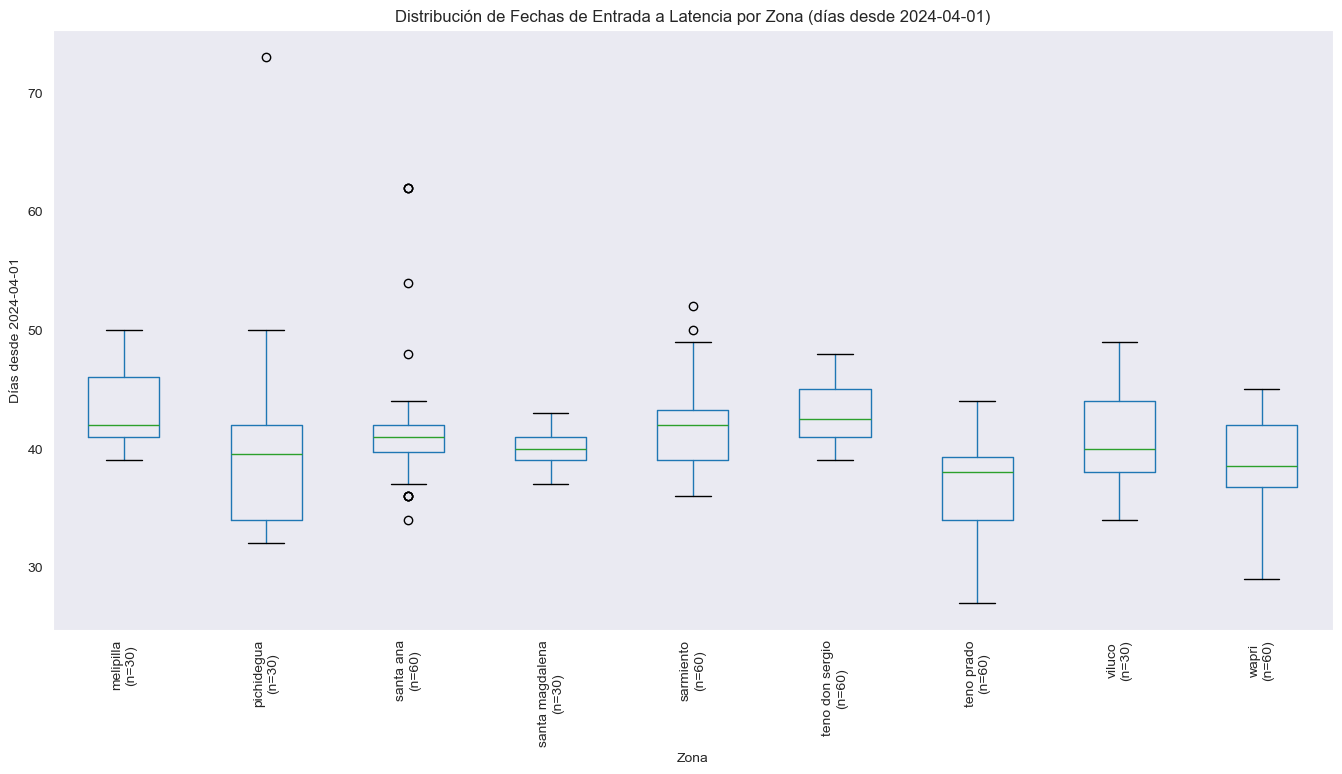

In [31]:
# Ahora veamos como distribuye el rango de fechas de entrada a latencia por zona
# Para eso hagamos un boxplot por zona de las fechas de entrada a latencia como dias desde el 2024-04-01
# Convertimos las fechas a dias desde el 2024-04-01
fecha_referencia = pd.to_datetime('2024-04-01')
entrada_a_latencia_merged['dias_desde_referencia'] = (pd.to_datetime(entrada_a_latencia_merged['fecha_entrada_latencia']) - fecha_referencia).dt.days
figsize = (16,8)
plt.figure(figsize=figsize)
entrada_a_latencia_merged.boxplot(column='dias_desde_referencia', by='zona', grid=False, figsize=figsize)
plt.title('Distribución de Fechas de Entrada a Latencia por Zona (días desde 2024-04-01)')
plt.suptitle('')

# Add to x-axis labels the amount of samples per zone
zone_counts = entrada_a_latencia_merged['zona'].value_counts().sort_index()
labels = [f"{zone}\n(n={zone_counts[zone]})" for zone in sorted(entrada_a_latencia_merged['zona'].unique())]
plt.gca().set_xticklabels(labels)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.xlabel('Zona')
plt.ylabel('Días desde 2024-04-01')
plt.show()


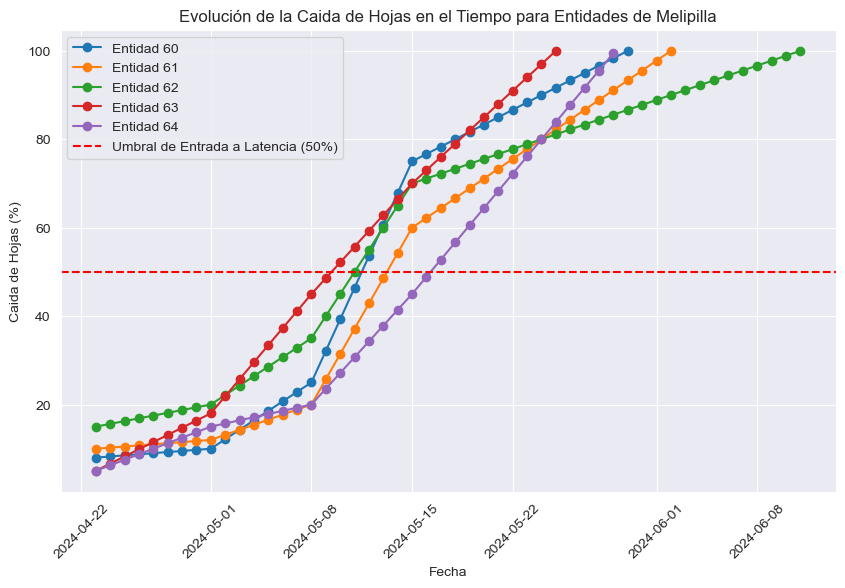

In [32]:
# Ploteemos un grafico de lineas para ver la evolucion de la caida de hojas en el tiempo para algunas entidades seleccionadas
# Para entidades de melipilla usando el dataset denso
sampled_entities = in_caida_hojas_merged[
    (in_caida_hojas_merged['zona'] == 'melipilla')
]['entidad_id'].unique()[:5]  # Tomemos las primeras 5 entidades de melipilla como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = serie_densa_df[serie_densa_df['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='fecha')
    plt.plot(data_entidad['fecha'], data_entidad['porcentaje_interp'], marker='o', label=f'Entidad {entidad}')
# Tilt the x-axis labels for better readability
plt.xticks(rotation=45)
# Add legend
plt.axhline(y=50, color='r', linestyle='--', label='Umbral de Entrada a Latencia (50%)')
plt.legend()
plt.title('Evolución de la Caida de Hojas en el Tiempo para Entidades de Melipilla')
plt.xlabel('Fecha')
plt.ylabel('Caida de Hojas (%)')
plt.show()

<Figure size 1600x800 with 0 Axes>

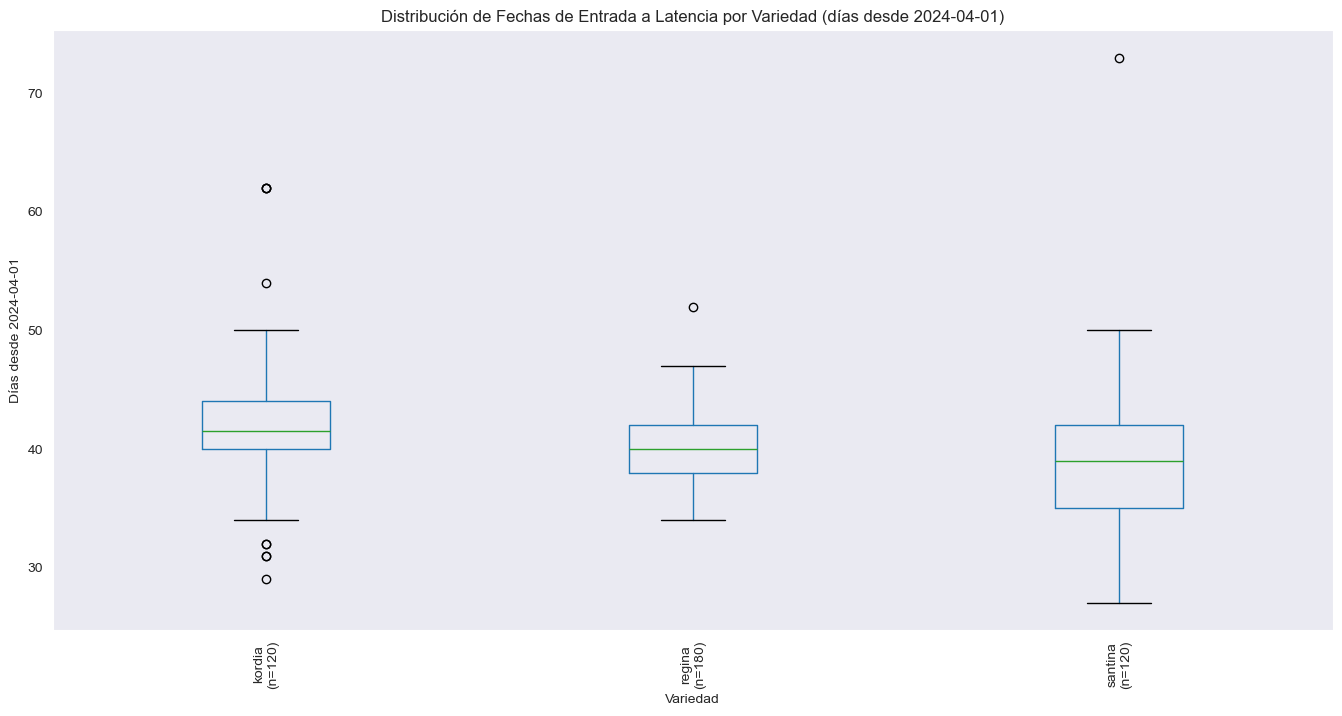

In [33]:
# Ahora hagamos los boxplots pero por variedad
figsize = (16,8)
plt.figure(figsize=figsize)
entrada_a_latencia_merged.boxplot(column='dias_desde_referencia', by='variedad', grid=False, figsize=figsize)
plt.title('Distribución de Fechas de Entrada a Latencia por Variedad (días desde 2024-04-01)')
plt.suptitle('')
# Add to x-axis labels the amount of samples per variety
variety_counts = entrada_a_latencia_merged['variedad'].value_counts().sort_index()
labels = [f"{variety}\n(n={variety_counts[variety]})" for variety in sorted(entrada_a_latencia_merged['variedad'].unique())]
plt.gca().set_xticklabels(labels)
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.xlabel('Variedad')
plt.ylabel('Días desde 2024-04-01')
plt.show()

<Figure size 1600x800 with 0 Axes>

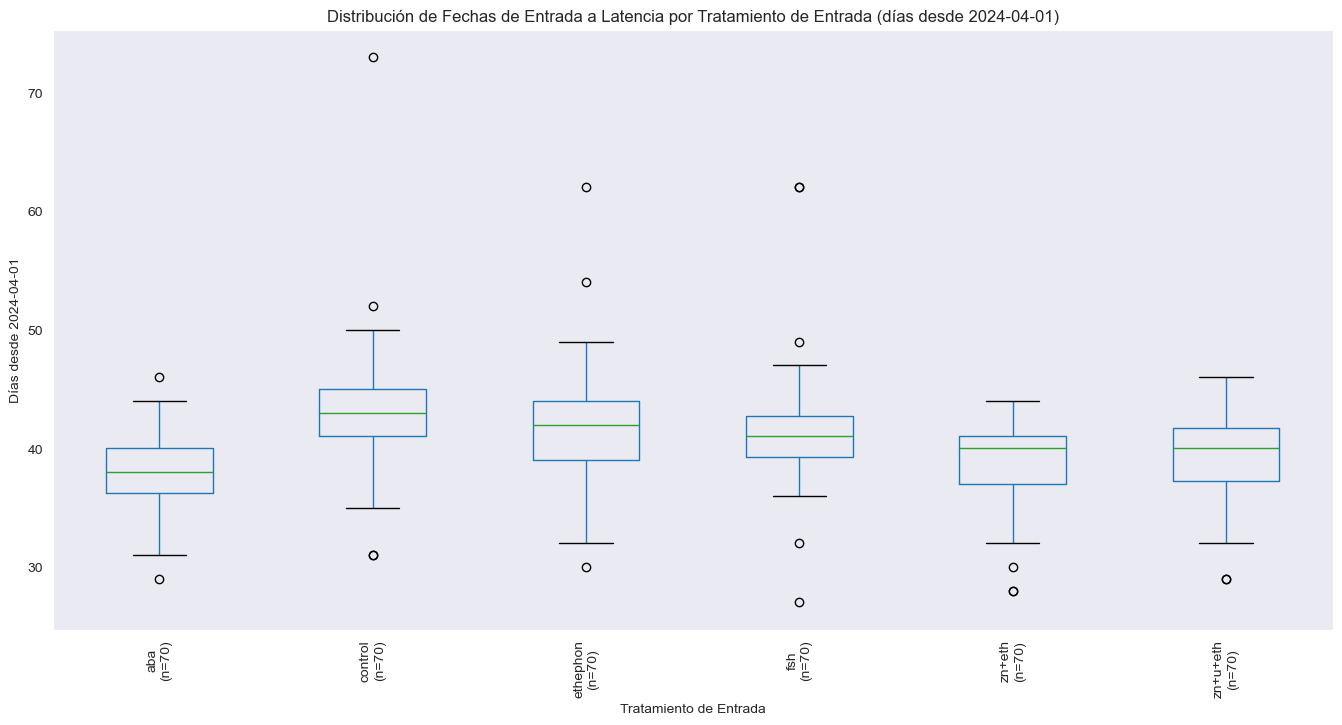

In [34]:
# Y por tratamiento de entrada
figsize = (16,8)
plt.figure(figsize=figsize)
entrada_a_latencia_merged.boxplot(column='dias_desde_referencia', by='tratamiento_entrada', grid=False, figsize=figsize)
plt.title('Distribución de Fechas de Entrada a Latencia por Tratamiento de Entrada (días desde 2024-04-01)')
plt.suptitle('')
# Add to x-axis labels the amount of samples per treatment
treatment_counts = entrada_a_latencia_merged['tratamiento_entrada'].value_counts().sort_index()
labels = [f"{treatment}\n(n={treatment_counts[treatment]})" for treatment in sorted(entrada_a_latencia_merged['tratamiento_entrada'].unique())]
plt.gca().set_xticklabels(labels)
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.xlabel('Tratamiento de Entrada')
plt.ylabel('Días desde 2024-04-01')
plt.show()

#### Genera Tabla de Entrada a Latencia

In [35]:
entrada_a_latencia_por_entidad.to_csv('entrada_a_latencia_por_entidad.csv', index=False)

#### Resumen
- Esta variable es crucial ya que define el inicio del periodo de latencia. Se uso un ajuste lineal para estimar la fecha exacta en que cada entidad cruzo el umbral del 50% de caida de hojas.
- Hay varianza en la fecha de entrada a latencia entre diferentes zonas y tratamientos más significativa. Pero entre variedades la diferencia es mucho menor. A priori todas entran en latencia en rangos similares a fechas pese a las diferencias menores, ahora se debe comprobar como se ve la salida de latencia.
- Se genero una tabla de reporte con la entidad_id y la fecha estimada de entrada a latencia para cada entidad. Esto es util para poder generar el dataset final.


### Entrada materia seca

In [36]:
# Primero revisemos que porcentaje de las entidades tiene datos de entrada de materia seca
entidades_con_materia_seca = in_materia_seca['entidad_id'].unique().tolist()
entidades_sin_materia_seca = list(set(entidades_unicas) - set(entidades_con_materia_seca))
porcentaje_con_materia_seca = (len(entidades_con_materia_seca) / len(entidades_unicas)) * 100
porcentaje_sin_materia_seca = (len(entidades_sin_materia_seca) / len(entidades_unicas)) * 100
print(f"Porcentaje de entidades con datos de entrada de materia seca: {porcentaje_con_materia_seca:.2f}%")
print(f"Porcentaje de entidades sin datos de entrada de materia seca: {porcentaje_sin_materia_seca:.2f}%")

Porcentaje de entidades con datos de entrada de materia seca: 100.00%
Porcentaje de entidades sin datos de entrada de materia seca: 0.00%


In [37]:
# Unamos los datos de materia seca con el maestro de entidades para ver la informacion completa
# Si falla pq no encuentra la entidad_id, levantar error
in_materia_seca_merged = in_materia_seca.merge(maestro_entidades, on='entidad_id', how='left', validate='many_to_one', indicator=True)
if (in_materia_seca_merged['_merge'] != 'both').sum() > 0:
    print("Fallaron uniones (deberia ser 0):", (in_materia_seca_merged['_merge'] != 'both').sum())
    raise ValueError("Fallo la union entre in_materia_seca y maestro_entidades")
print("Datos de entrada de materia seca unidos con maestro de entidades:")
in_materia_seca_merged.head()

Datos de entrada de materia seca unidos con maestro de entidades:


,entidad_id,fecha,muestreo,peso_fresco,peso_seco,porcentaje_humedad,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
0,0,2024-04-19,M1,0.4124,0.2157,52.303589,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1,both
1,1,2024-04-19,M1,0.3628,0.1819,50.137817,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2,both
2,2,2024-04-19,M1,0.3180,0.1591,50.031447,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3,both
3,3,2024-04-19,M1,0.5819,0.2839,48.788452,2,pichidegua,1,santina,3,zn+u+eth,6,control,4,both
4,4,2024-04-19,M1,0.3340,0.1667,49.910180,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5,both


In [38]:
# Fechas distintas por cada momento
momentos = in_materia_seca_merged['muestreo'].unique()
n_momentos = len(momentos)
for momento in momentos:
    fechas_momento = in_materia_seca_merged[in_materia_seca_merged['muestreo'] == momento]['fecha'].unique()
    print(f"Muestreo {momento}: {fechas_momento}")

Muestreo M1: ['2024-04-19' '2024-01-19' '2024-04-24' '2024-04-23' '2024-05-02'
 '2024-05-06' '2024-05-03' '2024-04-25' '2024-05-25']
Muestreo M2: ['2024-05-17' '2024-05-14' '2024-05-24' '2024-05-22']
Muestreo M3: ['2024-05-31' '2024-05-30' '2024-06-10' '2024-06-05' '2024-05-29'
 '2024-06-06']
Muestreo M4: ['2024-06-26' '2024-06-27' '2024-07-01' '2024-06-28']


In [39]:
# Tiene pesos negativos??
in_materia_seca_merged[['peso_fresco', 'peso_seco', 'porcentaje_humedad']].describe()

,peso_fresco,peso_seco,porcentaje_humedad
count,1671.000000,1671.000000,1.671000e+03
mean,0.556022,2.553290,7.862838e+02
std,0.204044,93.632571,3.022448e+04
min,-1.263400,-1.557000,-9.154008e+02
25%,0.427700,0.204750,4.608485e+01
50%,0.543800,0.258500,4.761816e+01
75%,0.678050,0.316800,4.887095e+01
max,1.479400,3827.760300,1.235559e+06


In [40]:
# Hay pesos negativos
in_materia_seca_merged.loc[
    (in_materia_seca_merged['peso_fresco'] < 0) |
    (in_materia_seca_merged['peso_seco'] < 0) |
    (in_materia_seca_merged['porcentaje_humedad'] < 0)
]

,entidad_id,fecha,muestreo,peso_fresco,peso_seco,porcentaje_humedad,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
647,167,2024-05-22,M2,-0.1969,0.3441,-174.758761,5,teno don sergio,0,regina,2,zn+eth,16,"dormex 1,5% + 2% ac. mineral",18,both
772,202,2024-05-14,M2,-0.0474,0.4339,-915.400844,7,wapri,0,regina,0,control,13,NaN,23,both
806,206,2024-05-29,M3,-0.2583,0.3448,-133.488192,7,wapri,0,regina,0,control,13,NaN,27,both
813,183,2024-07-01,M4,-0.1736,0.3067,-176.670507,7,wapri,0,regina,3,zn+u+eth,6,control,4,both
1066,256,2024-06-27,M4,0.3559,-0.0981,-27.563922,5,teno don sergio,2,kordia,4,ethephon,6,control,17,both
1111,271,2024-05-17,M2,-1.2634,-1.5570,123.238879,8,santa magdalena,0,regina,1,fsh,16,"dormex 1,5% + 2% ac. mineral",2,both
1610,410,2024-05-14,M2,0.9637,-0.2058,-21.355194,7,wapri,2,kordia,3,zn+u+eth,13,NaN,21,both


In [41]:
# Por ahora los voy a eliminar
in_materia_seca_merged_clean = in_materia_seca_merged.loc[
    (in_materia_seca_merged['peso_fresco'] >= 0) &
    (in_materia_seca_merged['peso_seco'] >= 0) &
    (in_materia_seca_merged['porcentaje_humedad'] >= 0)
]
print("Datos de entrada de materia seca limpios (sin negativos):")
in_materia_seca_merged_clean[['peso_fresco', 'peso_seco', 'porcentaje_humedad']].describe()

Datos de entrada de materia seca limpios (sin negativos):


,peso_fresco,peso_seco,porcentaje_humedad
count,1664.000000,1664.000000,1.664000e+03
mean,0.558734,2.564291,7.903884e+02
std,0.195981,93.829263,3.028795e+04
min,0.065200,0.020600,1.677523e+01
25%,0.428000,0.204800,4.609422e+01
50%,0.544200,0.258450,4.762030e+01
75%,0.680100,0.316625,4.887116e+01
max,1.479400,3827.760300,1.235559e+06


In [42]:
# Se encuentra un valor demasiado grande para porcentaje_humedad dado probablemente un error
# de tipeo. Vamos a descartar tambien los valores a 100 y dejamos como duda si es valido tener un valor a 100.
in_materia_seca_merged_clean = in_materia_seca_merged_clean.loc[
    in_materia_seca_merged_clean['porcentaje_humedad'] < 100
]
print("Datos de entrada de materia seca limpios (sin negativos y sin 100% humedad):")
in_materia_seca_merged_clean[['peso_fresco', 'peso_seco', 'porcentaje_humedad']].describe()

Datos de entrada de materia seca limpios (sin negativos y sin 100% humedad):


,peso_fresco,peso_seco,porcentaje_humedad
count,1658.000000,1658.000000,1658.000000
mean,0.559574,0.263626,47.627973
std,0.195770,0.089239,5.757225
min,0.065200,0.020600,16.775227
25%,0.428725,0.204725,46.093097
50%,0.544600,0.258300,47.616987
75%,0.680550,0.315400,48.867223
max,1.479400,0.644400,99.605600


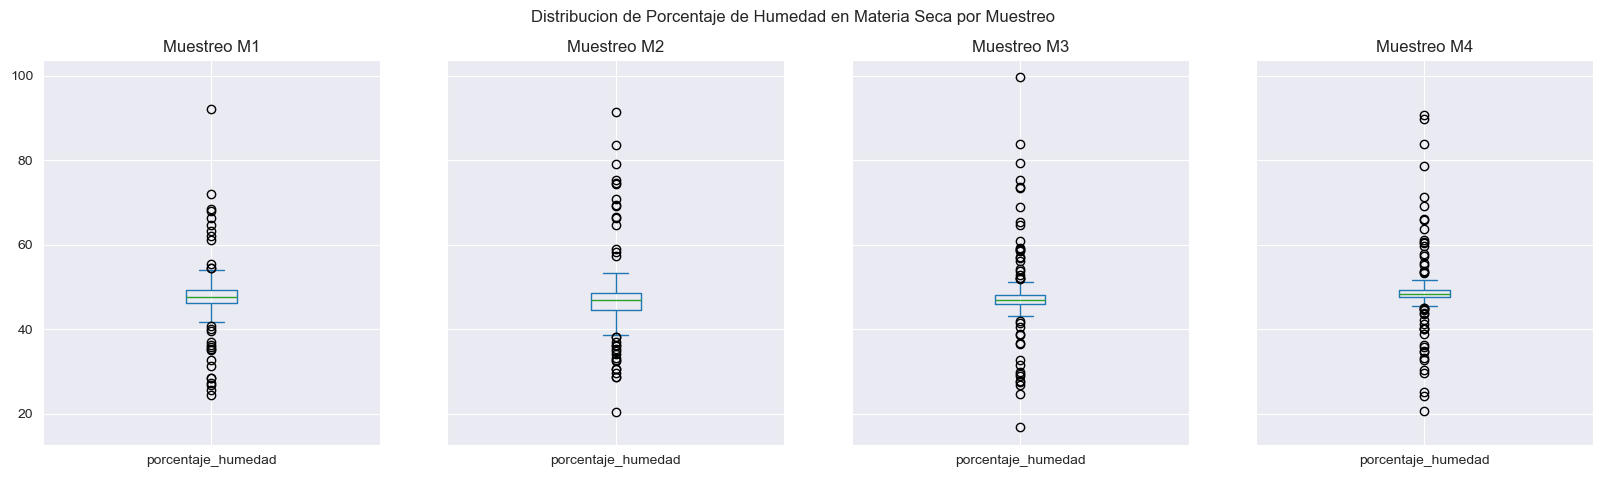

In [43]:
# Grafiquemos los valores de porcentaje_humedad por cada muestreo
fig, axes = plt.subplots(1, n_momentos, figsize=(5*n_momentos, 5), sharey=True)
for i, momento in enumerate(momentos):
    data_momento = in_materia_seca_merged_clean[in_materia_seca_merged_clean['muestreo'] == momento]
    axes[i] = data_momento['porcentaje_humedad'].plot(kind='box', ax=axes[i], title=f'Muestreo {momento}')
plt.suptitle('Distribucion de Porcentaje de Humedad en Materia Seca por Muestreo')
plt.show()

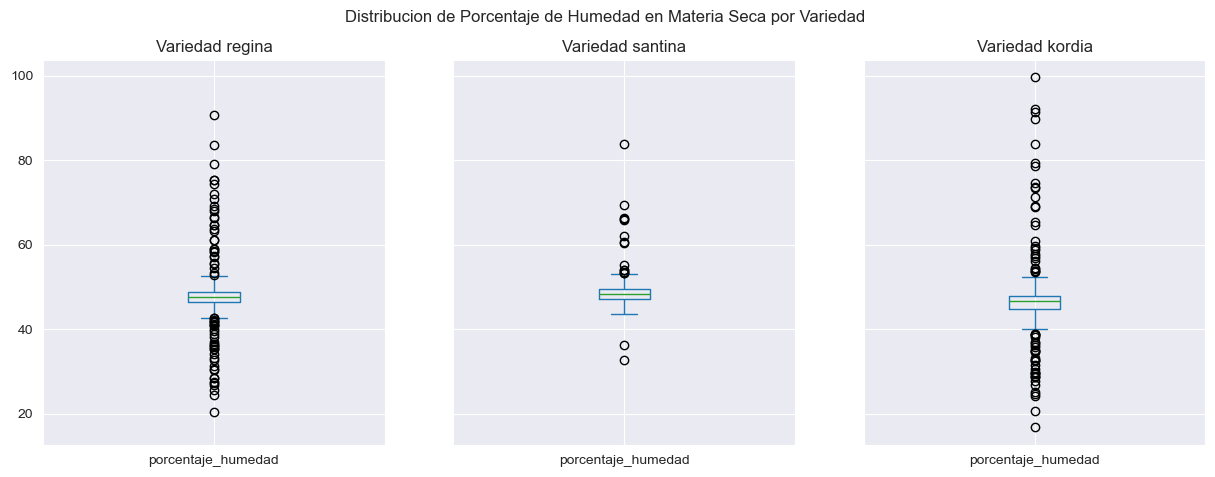

In [44]:
# Segun variedad
fig, axes = plt.subplots(1, len(maestro_variedades), figsize=(5*len(maestro_variedades), 5), sharey=True)
for i, variedad in enumerate(maestro_variedades['variedad'].unique()):
    data_variedad = in_materia_seca_merged_clean[in_materia_seca_merged_clean['variedad'] == variedad]
    axes[i] = data_variedad['porcentaje_humedad'].plot(kind='box', ax=axes[i], title=f'Variedad {variedad}')
plt.suptitle('Distribucion de Porcentaje de Humedad en Materia Seca por Variedad')
plt.show()

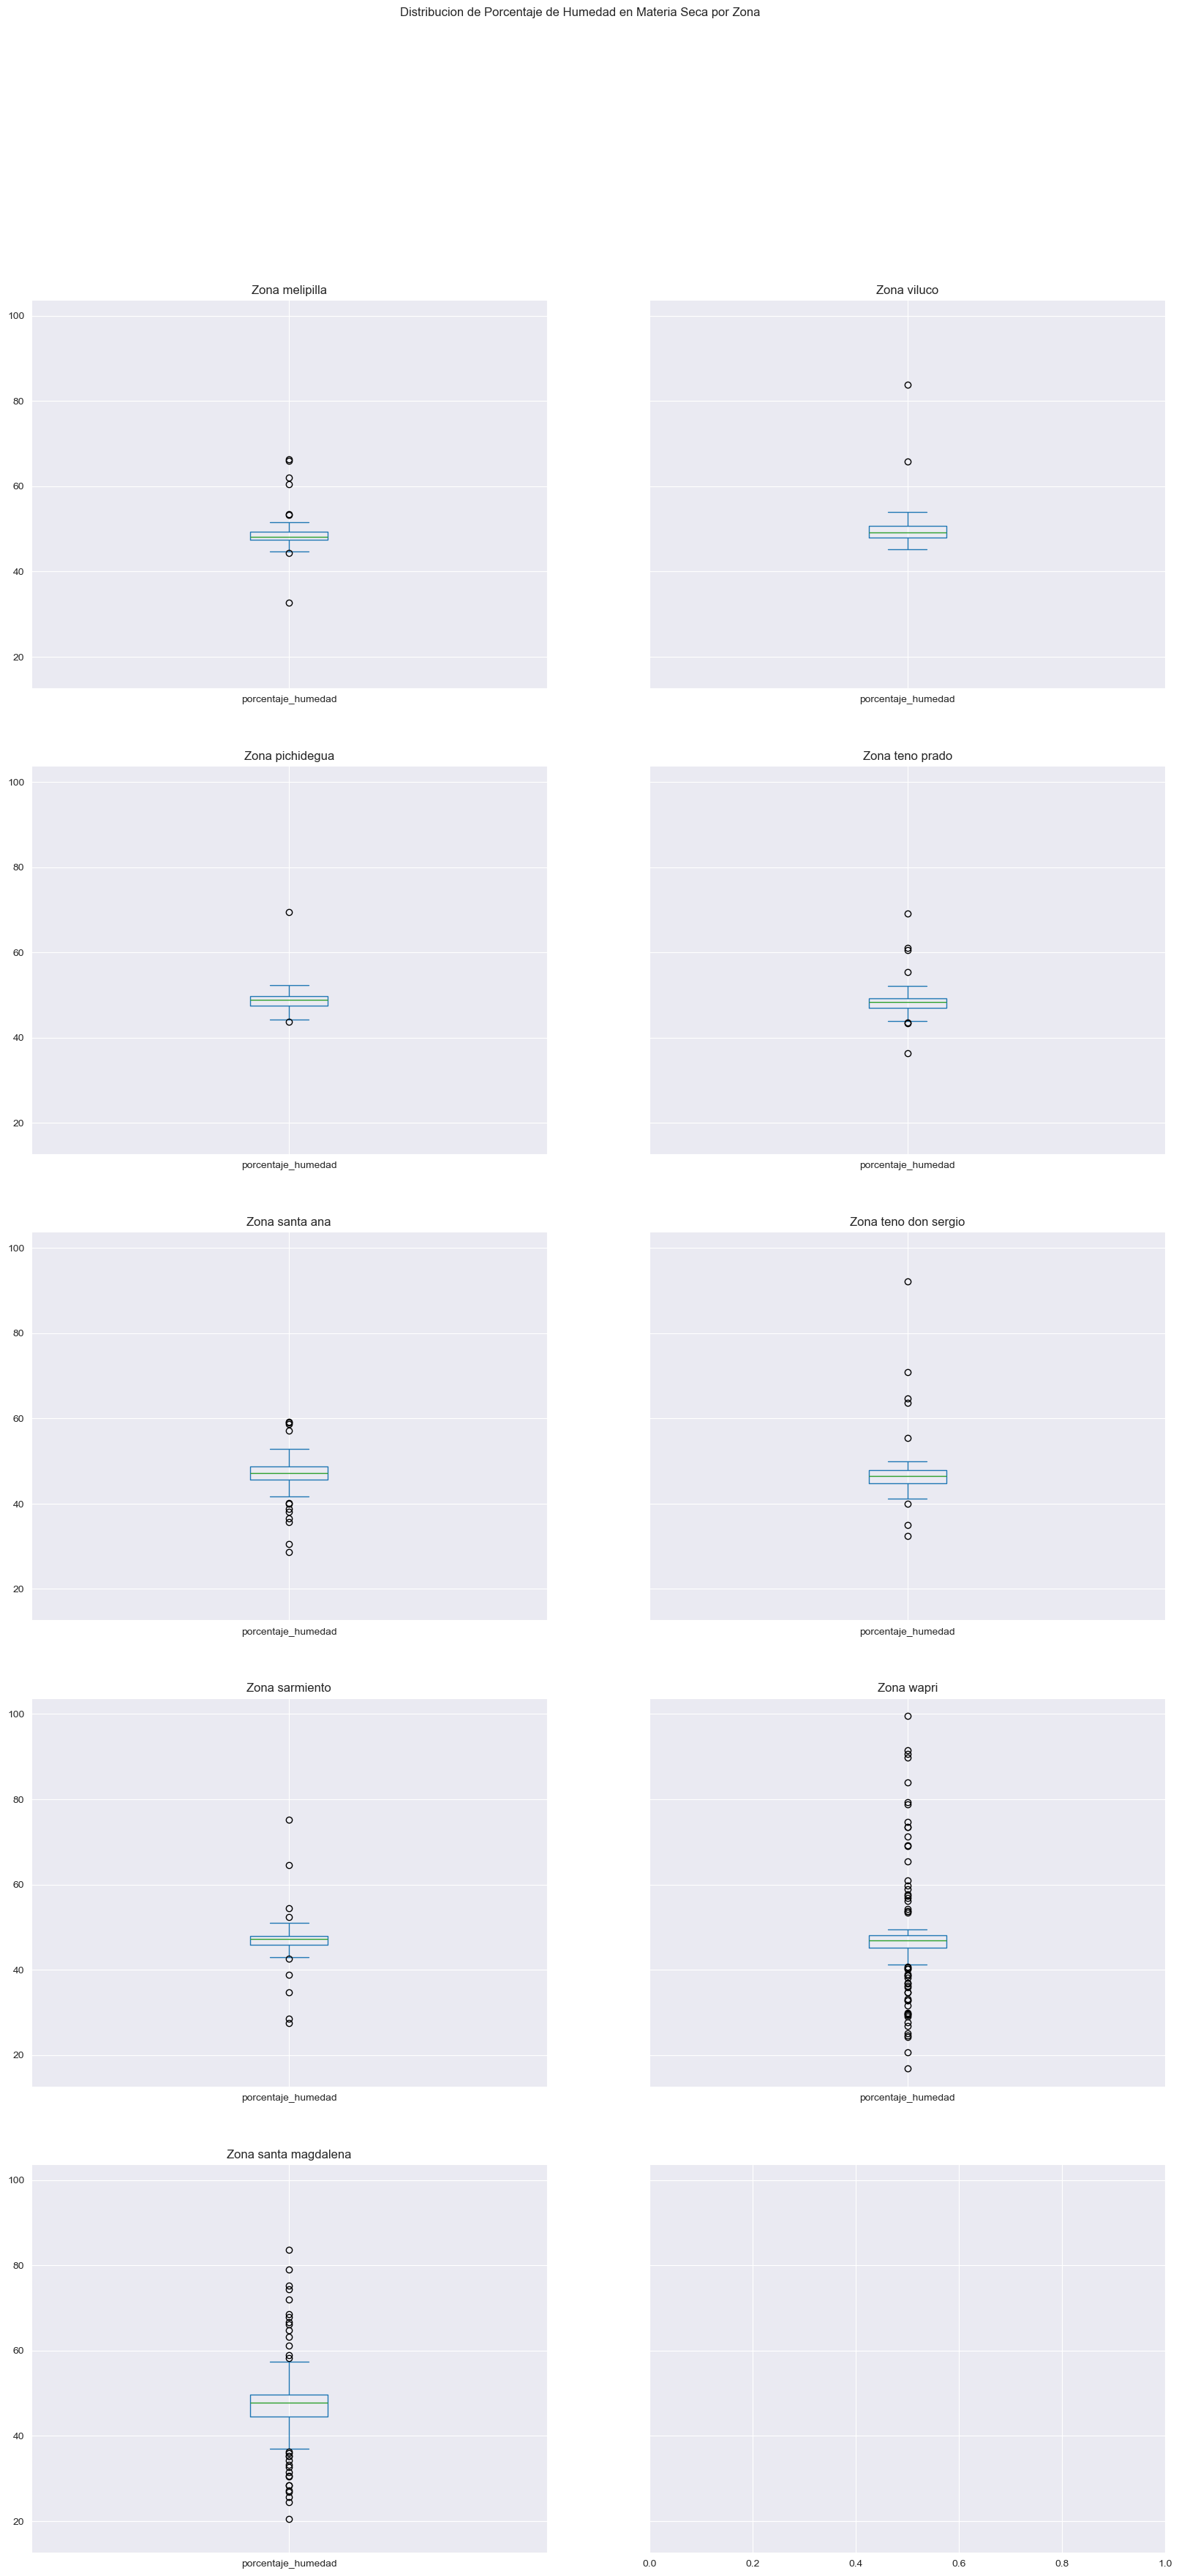

In [45]:
# Segun zona
fig, axes = plt.subplots(5, len(maestros_zonas) // 4, figsize=(20, 40), sharey=True)
axes = axes.flatten()
for i, zona in enumerate(maestros_zonas['zona'].unique()):
    data_zona = in_materia_seca_merged_clean[in_materia_seca_merged_clean['zona'] == zona]
    axes[i] = data_zona['porcentaje_humedad'].plot(kind='box', ax=axes[i], title=f'Zona {zona}')
plt.suptitle('Distribucion de Porcentaje de Humedad en Materia Seca por Zona')
plt.show()

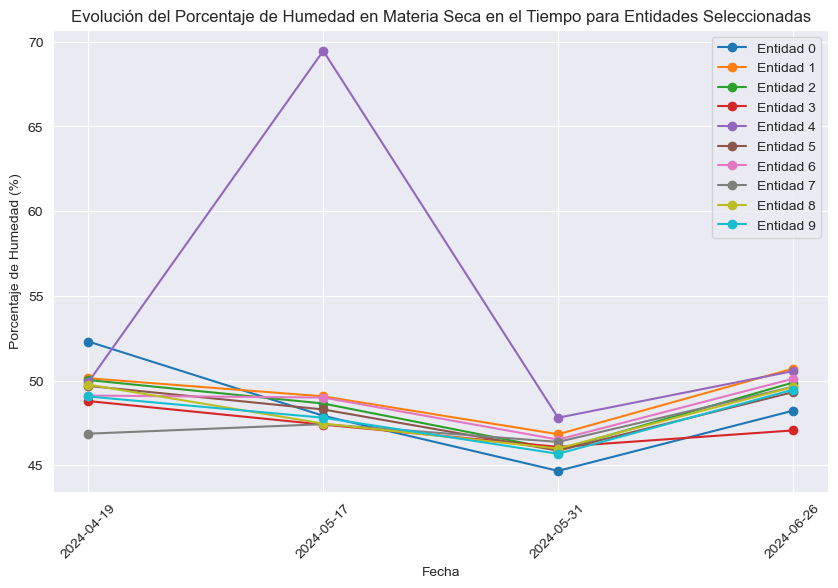

In [46]:
# Y la progresion para una entidad a lo largo del tiempo
sampled_entities = in_materia_seca_merged_clean['entidad_id'].unique()[:10]  # Tomemos las primeras 5 entidades como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = in_materia_seca_merged_clean[in_materia_seca_merged_clean['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='fecha')
    plt.plot(data_entidad['fecha'], data_entidad['porcentaje_humedad'], marker='o', label=f'Entidad {entidad}')
# Tilt the x-axis labels for better readability
plt.xticks(rotation=45)
# Add legend
plt.legend()
plt.title('Evolución del Porcentaje de Humedad en Materia Seca en el Tiempo para Entidades Seleccionadas')
plt.xlabel('Fecha')
plt.ylabel('Porcentaje de Humedad (%)')
plt.show()

In [47]:
# No veo nada aparente en el grafico excepto que le pasa a entidad 4 :0
# Podriamos añadir estas variables del momento de muestreo más cercano a la fecha de ingreso a latencia
# La idea actual es variar los requerimientos de horas frio para cada entidad en base a estas variables de entrada

disminucion_porcentual = 100 * (in_materia_seca_merged.shape[0] - in_materia_seca_merged_clean.shape[0]) / in_materia_seca_merged.shape[0]
# Veamos cuantos datos se eliminaron por los filtros
print("Cantidad de datos originales de materia seca:", in_materia_seca_merged.shape[0])
print("Cantidad de datos de materia seca despues de eliminar negativos y 100% humedad:", in_materia_seca_merged_clean.shape[0])
print(f"Porcentualmente se eliminaron: {disminucion_porcentual:.2f}% de los datos originales.")

Cantidad de datos originales de materia seca: 1680
Cantidad de datos de materia seca despues de eliminar negativos y 100% humedad: 1658
Porcentualmente se eliminaron: 1.31% de los datos originales.


In [48]:
in_materia_seca_merged_clean.to_csv('in_materia_seca_merged_clean.csv', index=False)

#### Resumen
- La variable porcentaje_humedad es dificil de interpretar, por un lado, a nivel de medias no hay casi variacion al variar muestreo, variedad o zona. Pero por otro lado hay muchos outliers lo que me hace pensar que puede tener algun efecto en la entrada de latencia.
- Se identificaron y eliminaron valores negativos y un valor anómalo de 100% de humedad. Esto es inconveniente porque reduce la cantidad de datos disponibles del 100% original.
- Se deja una tabla de reporte refinada sin estos valores anomalos.

## Exploracion datos de salida


### Salida Brotacion en Campo

In [49]:
out_brotacion_campo.head()

,entidad_id,fecha,momento,numero_dardo,cantidad_yemas,cantidad_yemas_brotadas
0,360,2024-09-04,M1,1,9,4.0
1,360,2024-09-04,M1,2,9,6.0
2,360,2024-09-04,M1,3,4,2.0
3,360,2024-09-04,M1,4,7,2.0
4,360,2024-09-04,M1,5,8,6.0


In [50]:
# Primero revisemos que porcentaje de las entidades tiene datos de salida de brotacion en campo
entidades_con_brotacion_campo = out_brotacion_campo['entidad_id'].unique().tolist()
entidades_sin_brotacion_campo = list(set(entidades_unicas) - set(entidades_con_brotacion_campo))
porcentaje_con_brotacion_campo = (len(entidades_con_brotacion_campo) / len(entidades_unicas)) * 100
porcentaje_sin_brotacion_campo = (len(entidades_sin_brotacion_campo) / len(entidades_unicas)) * 100
print(f"Porcentaje de entidades con datos de salida de brotacion en campo: {porcentaje_con_brotacion_campo:.2f}%")
print(f"Porcentaje de entidades sin datos de salida de brotacion en campo: {porcentaje_sin_brotacion_campo:.2f}%")

Porcentaje de entidades con datos de salida de brotacion en campo: 66.67%
Porcentaje de entidades sin datos de salida de brotacion en campo: 33.33%


In [51]:
# Veamos las entidades que no tienen salida de brotacion en campo
maestro_entidades.loc[maestro_entidades['entidad_id'].isin(entidades_sin_brotacion_campo)].head()

,entidad_id,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue
20,20,2,pichidegua,1,santina,3,zn+u+eth,13,NaN,21
21,21,2,pichidegua,1,santina,2,zn+eth,13,NaN,22
22,22,2,pichidegua,1,santina,0,control,13,NaN,23
23,23,2,pichidegua,1,santina,5,aba,13,NaN,24
24,24,2,pichidegua,1,santina,3,zn+u+eth,13,NaN,25


In [52]:
# Se tienen varias mediciones por entidad y momento debido a que se contabilizan varias ramas por entidad
#out_brotacion_campo.groupby(['entidad_id', 'fecha', 'momento']).size().reset_index(name='count')

In [56]:
# Vamos a ver el porcentaje de brotacion por momento por entidad para ver su evolucion en el tiempo
out_brotacion_campo_grouped = out_brotacion_campo.groupby(['entidad_id', 'fecha', 'momento']).agg({
    'cantidad_yemas': 'sum',
    'cantidad_yemas_brotadas': 'sum'
}).reset_index()
out_brotacion_campo_grouped['porcentaje_brotacion'] = 100 * out_brotacion_campo_grouped['cantidad_yemas_brotadas'] / out_brotacion_campo_grouped['cantidad_yemas']
print("Datos de salida de brotacion en campo agrupados por entidad y momento:")
out_brotacion_campo_grouped.head()

Datos de salida de brotacion en campo agrupados por entidad y momento:


,entidad_id,fecha,momento,cantidad_yemas,cantidad_yemas_brotadas,porcentaje_brotacion
0,0,2024-09-02,M1,36,33.0,91.666667
1,0,2024-09-09,M2,36,36.0,100.000000
2,0,2024-09-16,M3,36,36.0,100.000000
3,1,2024-09-02,M1,25,17.0,68.000000
4,1,2024-09-09,M2,25,20.0,80.000000


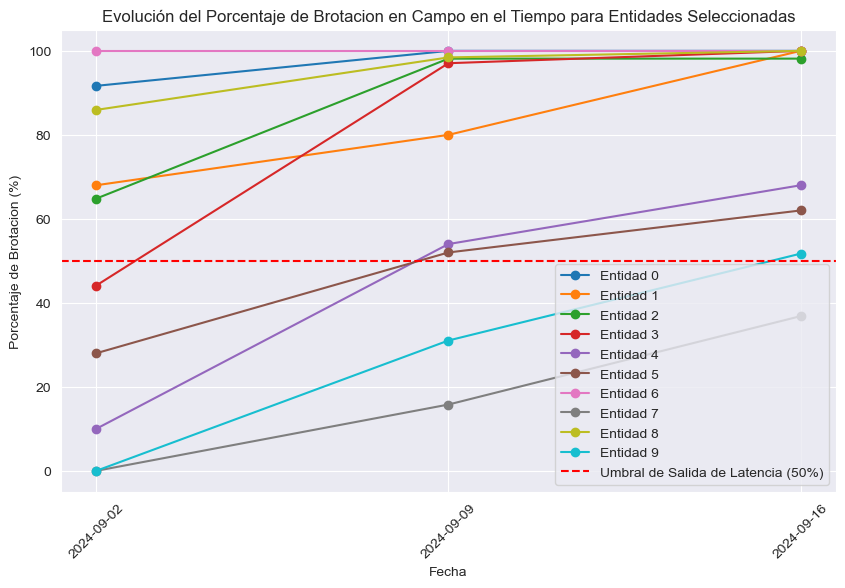

In [57]:
# Grafiquemos el porcentaje_brotacion para la misma entidad en distintos momentos
# Y la progresion para una entidad a lo largo del tiempo
sampled_entities = out_brotacion_campo_grouped['entidad_id'].unique()[:10]  # Tomemos las primeras 5 entidades como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = out_brotacion_campo_grouped[out_brotacion_campo_grouped['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='fecha')
    plt.plot(data_entidad['fecha'], data_entidad['porcentaje_brotacion'], marker='o', label=f'Entidad {entidad}')
# Tilt the x-axis labels for better readability
plt.xticks(rotation=45)
# Add legend
plt.legend()
plt.title('Evolución del Porcentaje de Brotacion en Campo en el Tiempo para Entidades Seleccionadas')
# Vertical line at y=50 to mark 50% brotacion aka salida de latencia
plt.axhline(y=50, color='r', linestyle='--', label='Umbral de Salida de Latencia (50%)')
plt.legend()
plt.xlabel('Fecha')
plt.ylabel('Porcentaje de Brotacion (%)')
plt.show()


In [58]:
# Al igual que antes vamos a interpolar linealmente esta serie temporal para estimar la fecha exacta en que cada entidad cruzo el umbral del 50%
def interpolar_y_fecha_50_brotacion(group):
    g = group.sort_values("fecha").copy()
    g['fecha'] = pd.to_datetime(g['fecha'])
    # conservar columnas necesarias y quitar filas sin porcentaje
    g = g[['entidad_id', 'fecha', 'porcentaje_brotacion']].dropna(subset=['porcentaje_brotacion'])
    if g.empty:
        return pd.DataFrame(columns=['entidad_id', 'fecha', 'porcentaje_interp'])
    # convertir fechas a número de días desde la mínima fecha
    t = (g['fecha'] - g['fecha'].min()).dt.total_seconds() / 86400.0
    y = g['porcentaje_brotacion'].values
    # si solo hay un punto no se puede estimar pendiente -> devolver ese punto
    if len(y) == 1:
        return pd.DataFrame({
            'entidad_id': [g['entidad_id'].iloc[0]],
            'fecha': [g['fecha'].iloc[0]],
            'porcentaje_interp': [y[0]]
        })
    # interpolador con extrapolación permitida
    f = interp1d(t, y, kind='linear', fill_value='extrapolate', assume_sorted=True)
    # pendiente del último par de puntos
    t_vals = t.values
    slope = (y[-1] - y[-2]) / (t_vals[-1] - t_vals[-2]) if (t_vals[-1] - t_vals[-2]) != 0 else 0.0
    # determinar hasta dónde generar la grilla (en días)
    y_last = y[-1]
    if y_last >= 100:
        # ya alcanzó 100 en los datos: buscar primer cruce en la malla
        t_dense = np.arange(t_vals.min(), t_vals[-1] + 1e-6, 0.1)
        y_dense = f(t_dense)
        cruzamientos = np.where(y_dense >= 100)[0]
        if len(cruzamientos) > 0:
            t_end = t_dense[cruzamientos[0]]
        else:
            t_end = t_vals[-1]
    else:
        if slope > 0:
            # días necesarios para llegar a 100 usando la pendiente del último tramo
            days_needed = (100.0 - y_last) / slope
            t_end = t_vals[-1] + max(days_needed, 0.0)
        else:
            # no se puede alcanzar 100 con pendiente no positiva -> quedar en el último día
            t_end = t_vals[-1]
    # generar grilla diaria desde el mínimo hasta t_end
    t_new = np.arange(t_vals.min(), t_end + 1e-6, 1.0)
    y_new = f(t_new)
    # limitar a 100 como máximo y a 0 como mínimo por seguridad
    y_new = np.clip(y_new, 0.0, 100.0)
    serie_item = pd.DataFrame({
        'entidad_id': g['entidad_id'].iloc[0],
        'fecha': g['fecha'].min() + pd.to_timedelta(t_new, unit='D'),
        'porcentaje_interp': y_new
    })
    return serie_item


In [59]:
test_group = out_brotacion_campo_grouped[out_brotacion_campo_grouped['entidad_id'] == 0][['entidad_id', 'fecha','porcentaje_brotacion']]
serie_item = interpolar_y_fecha_50_brotacion(test_group)
fecha_50   = find_fecha_50(serie_item)
print("Fecha estimada de cruce del umbral del 50% de brotacion para la entidad 0:", fecha_50)
serie_item

Fecha estimada de cruce del umbral del 50% de brotacion para la entidad 0: 2024-09-02 00:00:00


,entidad_id,fecha,porcentaje_interp
0,0,2024-09-02,91.666667
1,0,2024-09-03,92.857143
2,0,2024-09-04,94.047619
3,0,2024-09-05,95.238095
4,0,2024-09-06,96.428571
5,0,2024-09-07,97.619048
6,0,2024-09-08,98.809524
7,0,2024-09-09,100.000000


In [60]:
# Ahora apliquemos esta función a todas las entidades
result_list = []
serie_densa_list = []

for entidad_id, group in out_brotacion_campo_grouped.groupby('entidad_id'):
    serie_item = interpolar_y_fecha_50_brotacion(group[['entidad_id', 'fecha','porcentaje_brotacion']])
    serie_densa_list.append(serie_item)

    fecha_50  = find_fecha_50(serie_item)
    result_list.append({
        'entidad_id': entidad_id,
        'fecha_50': fecha_50
    })

# Concatenar todos los resultados
fecha_50_brotacion_df = pd.DataFrame(result_list)
serie_densa_brotacion_df = pd.concat(serie_densa_list, ignore_index=True)
print("Fechas estimadas de cruce del umbral del 50% de brotacion:")
fecha_50_brotacion_df

C:\Users\gusta\miniforge3\envs\cherry\Lib\site-packages\scipy\interpolate\_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
C:\Users\gusta\miniforge3\envs\cherry\Lib\site-packages\scipy\interpolate\_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


Fechas estimadas de cruce del umbral del 50% de brotacion:


,entidad_id,fecha_50
0,0,2024-09-02
1,1,2024-09-02
2,2,2024-09-02
3,3,2024-09-03
4,4,2024-09-09
...,...,...
275,405,2024-09-13
276,406,2024-09-16
277,407,2024-09-06
278,408,2024-09-06


Text(0, 0.5, 'Brotacion en Campo (%)')

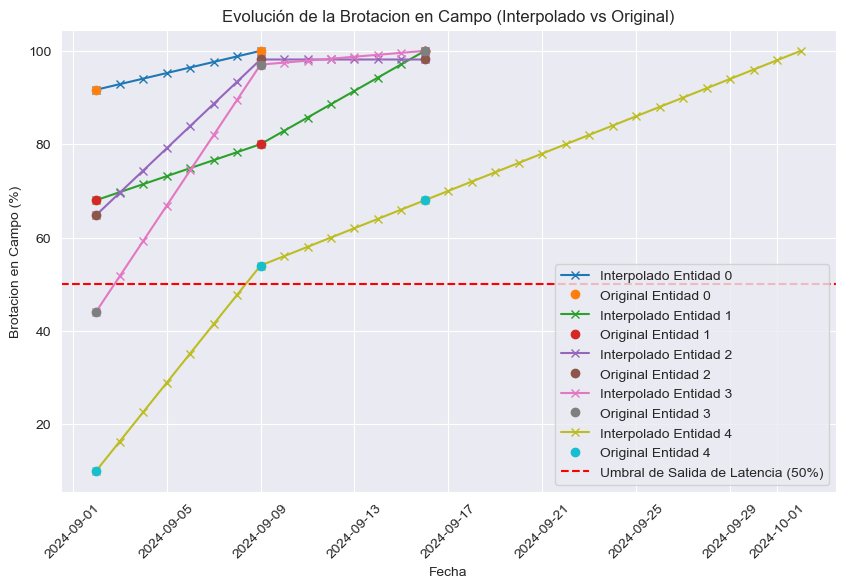

In [61]:
# Ploteemos algunas series densas para verificar visualmente
# Tomemos las primeras 5 entidades como muestra y marquemos los puntos originales de un color y los interpolados de otro
sampled_entities = out_brotacion_campo_grouped['entidad_id'].unique()[:5]  # Tomemos las primeras 5 entidades como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = out_brotacion_campo_grouped[out_brotacion_campo_grouped['entidad_id'] == entidad]
    data_serie = serie_densa_brotacion_df[serie_densa_brotacion_df['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='fecha')
    data_serie = data_serie.sort_values(by='fecha')
    data_entidad['fecha'] = pd.to_datetime(data_entidad['fecha'])
    plt.plot(data_serie['fecha'], data_serie['porcentaje_interp'], '-x', label=f'Interpolado Entidad {entidad}')
    plt.plot(data_entidad['fecha'], data_entidad['porcentaje_brotacion'], 'o', label=f'Original Entidad {entidad}')
# Tilt the x-axis labels for better readability
plt.xticks(rotation=45)
# Add legend
plt.axhline(y=50, color='r', linestyle='--', label='Umbral de Salida de Latencia (50%)')
plt.legend()
plt.title('Evolución de la Brotacion en Campo (Interpolado vs Original)')
plt.xlabel('Fecha')
plt.ylabel('Brotacion en Campo (%)')


In [62]:
# Ahora generemos la tabla de salida de latencia por entidad
salida_de_latencia_por_entidad = fecha_50_brotacion_df.rename(columns={'fecha_50':'fecha_salida_latencia'})
salida_de_latencia_por_entidad.describe()

,entidad_id,fecha_salida_latencia
count,280.00000,280
mean,204.50000,2024-09-10 01:01:42.857142784
min,0.00000,2024-09-02 00:00:00
25%,99.75000,2024-09-05 00:00:00
50%,204.50000,2024-09-11 00:00:00
75%,309.25000,2024-09-13 00:00:00
max,409.00000,2024-09-26 00:00:00
std,121.28804,NaN


In [63]:
# Veamos como distribuye el rango de fechas de salida de latencia por zona
# Para eso hagamos un boxplot por zona de las fechas de salida de latencia como dias desde el 2024-09-01
# Convertimos las fechas a dias desde el 2024-09-01
fecha_referencia_salida = pd.to_datetime('2024-09-01')
salida_de_latencia_por_entidad_merged = salida_de_latencia_por_entidad.merge(maestro_entidades, on='entidad_id', how='left', validate='many_to_one', indicator=True)
if (salida_de_latencia_por_entidad_merged['_merge'] != 'both').sum() > 0:
    print("Fallaron uniones (deberia ser 0):", (salida_de_latencia_por_entidad_merged['_merge'] != 'both').sum())
    raise ValueError("Fallo la union entre salida_de_latencia_por_entidad y maestro_entidades")
salida_de_latencia_por_entidad_merged['dias_desde_referencia'] = (pd.to_datetime(salida_de_latencia_por_entidad_merged['fecha_salida_latencia']) - fecha_referencia_salida).dt.days
salida_de_latencia_por_entidad_merged

,entidad_id,fecha_salida_latencia,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge,dias_desde_referencia
0,0,2024-09-02,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1,both,1
1,1,2024-09-02,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2,both,1
2,2,2024-09-02,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3,both,1
3,3,2024-09-03,2,pichidegua,1,santina,3,zn+u+eth,6,control,4,both,2
4,4,2024-09-09,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5,both,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,405,2024-09-13,7,wapri,2,kordia,0,control,6,control,16,both,12
276,406,2024-09-16,7,wapri,2,kordia,4,ethephon,6,control,17,both,15
277,407,2024-09-06,7,wapri,2,kordia,2,zn+eth,16,"dormex 1,5% + 2% ac. mineral",18,both,5
278,408,2024-09-06,7,wapri,2,kordia,4,ethephon,12,erger 5% + nca 4%,19,both,5


<Figure size 1600x800 with 0 Axes>

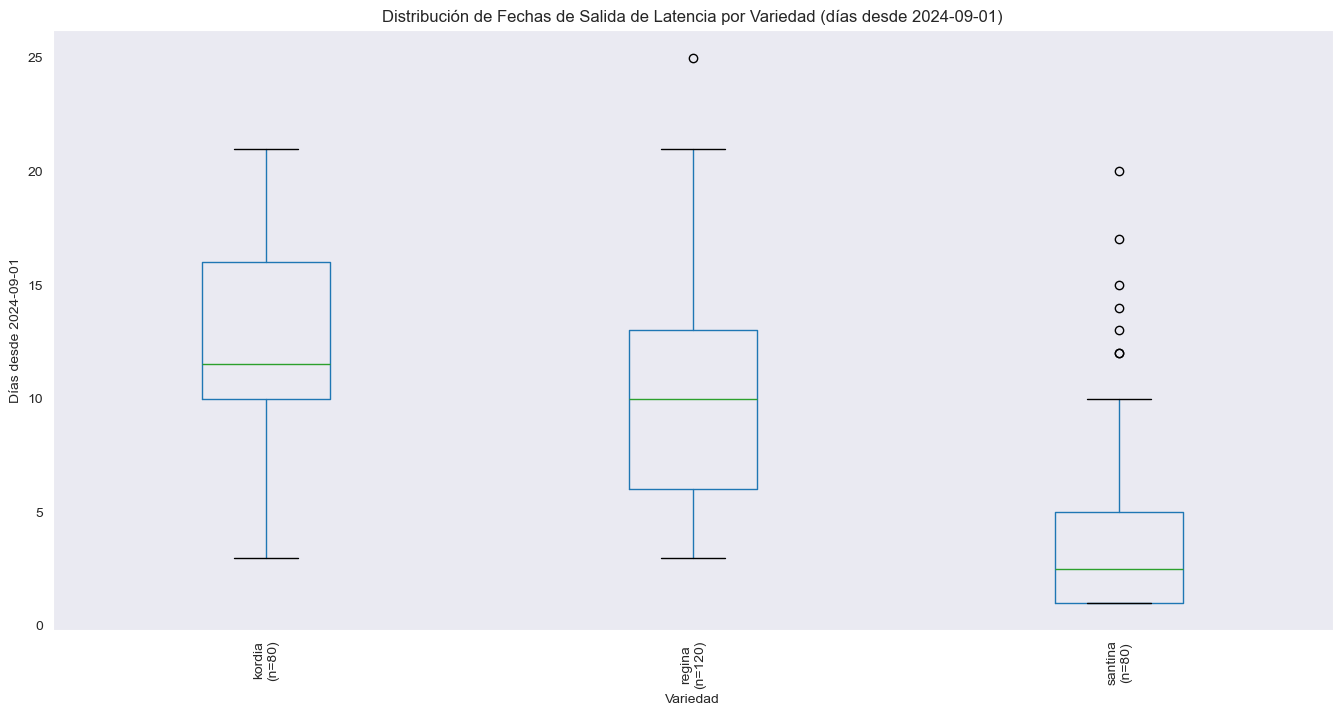

In [64]:
# Segun variedad
figsize = (16,8)
plt.figure(figsize=figsize)
salida_de_latencia_por_entidad_merged.boxplot(column='dias_desde_referencia', by='variedad', grid=False, figsize=figsize)
plt.title('Distribución de Fechas de Salida de Latencia por Variedad (días desde 2024-09-01)')
plt.suptitle('')
# Add to x-axis labels the amount of samples per variety
variety_counts = salida_de_latencia_por_entidad_merged['variedad'].value_counts().sort_index()
labels = [f"{variety}\n(n={variety_counts[variety]})" for variety in sorted(salida_de_latencia_por_entidad_merged['variedad'].unique())]

plt.gca().set_xticklabels(labels)
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.xlabel('Variedad')
plt.ylabel('Días desde 2024-09-01')
plt.show()

<Figure size 1600x800 with 0 Axes>

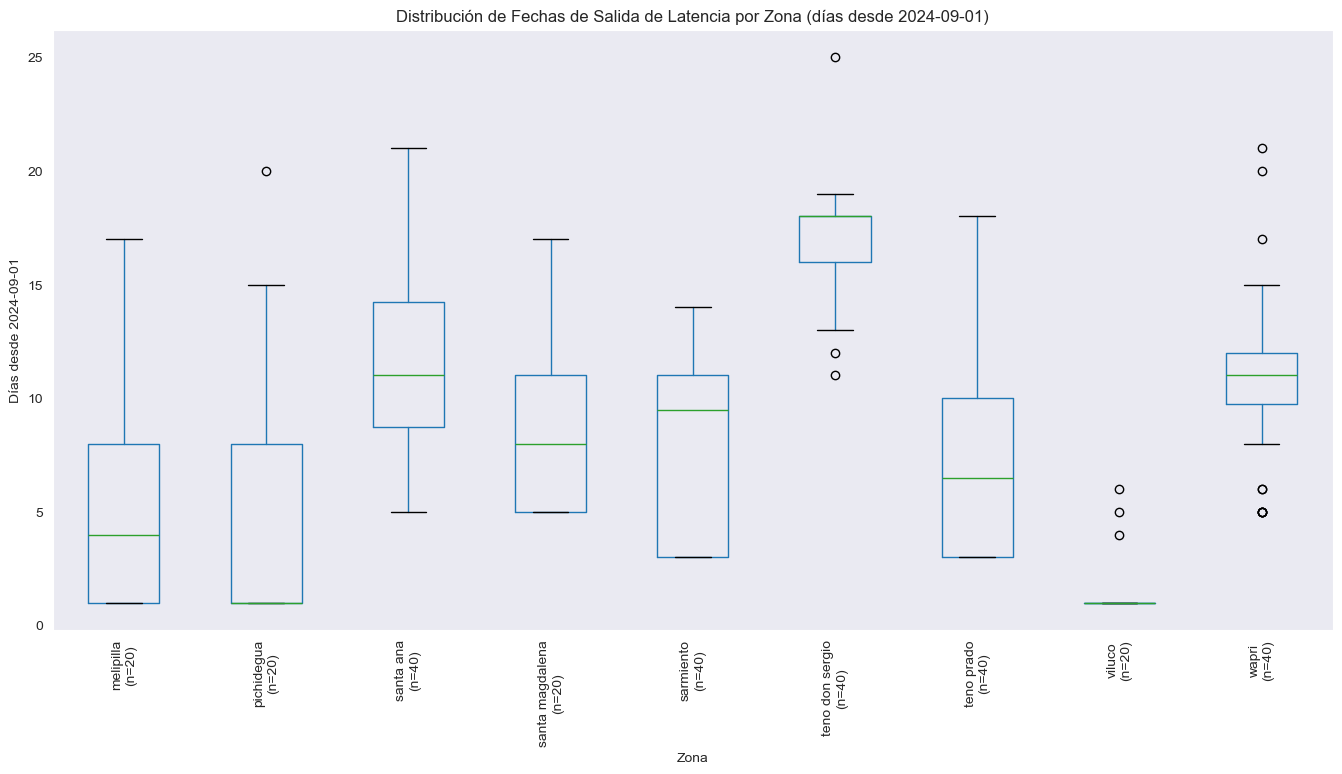

In [65]:
# Por zona
figsize = (16,8)
plt.figure(figsize=figsize)
salida_de_latencia_por_entidad_merged.boxplot(column='dias_desde_referencia', by='zona', grid=False, figsize=figsize)
plt.title('Distribución de Fechas de Salida de Latencia por Zona (días desde 2024-09-01)')
plt.suptitle('')
# Add to x-axis labels the amount of samples per zone
zone_counts = salida_de_latencia_por_entidad_merged['zona'].value_counts().sort_index()
labels = [f"{zone}\n(n={zone_counts[zone]})" for zone in sorted(salida_de_latencia_por_entidad_merged['zona'].unique())]
plt.gca().set_xticklabels(labels)
# Rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.xlabel('Zona')
plt.ylabel('Días desde 2024-09-01')
plt.show()

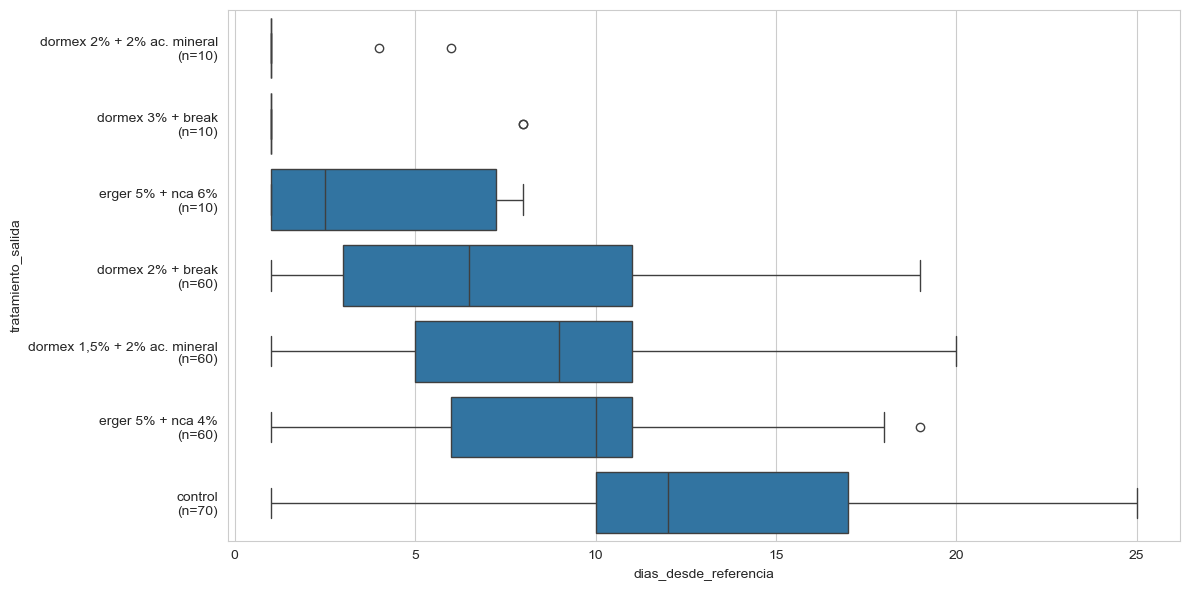

In [66]:
# Por tratamiento de salida usando seaborns para tener el plot horizontal y ordenado

# Preparar estadísticas y orden por mediana
grp = salida_de_latencia_por_entidad_merged.groupby('tratamiento_salida')['dias_desde_referencia']
stats = grp.agg(['median', 'count']).sort_values('median')
order = stats.index.tolist()

# Tamaño dinámico
n = len(order)
figsize = (12, max(6, 0.4 * n))

plt.figure(figsize=figsize)
sns.set_style("whitegrid")

ax = sns.boxplot(
    x='dias_desde_referencia',
    y='tratamiento_salida',
    data=salida_de_latencia_por_entidad_merged,
    order=order,
    orient='h'
)

ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([f"{idx}\n(n={int(stats.loc[idx,'count'])})" for idx in order])
plt.tight_layout()
plt.show()

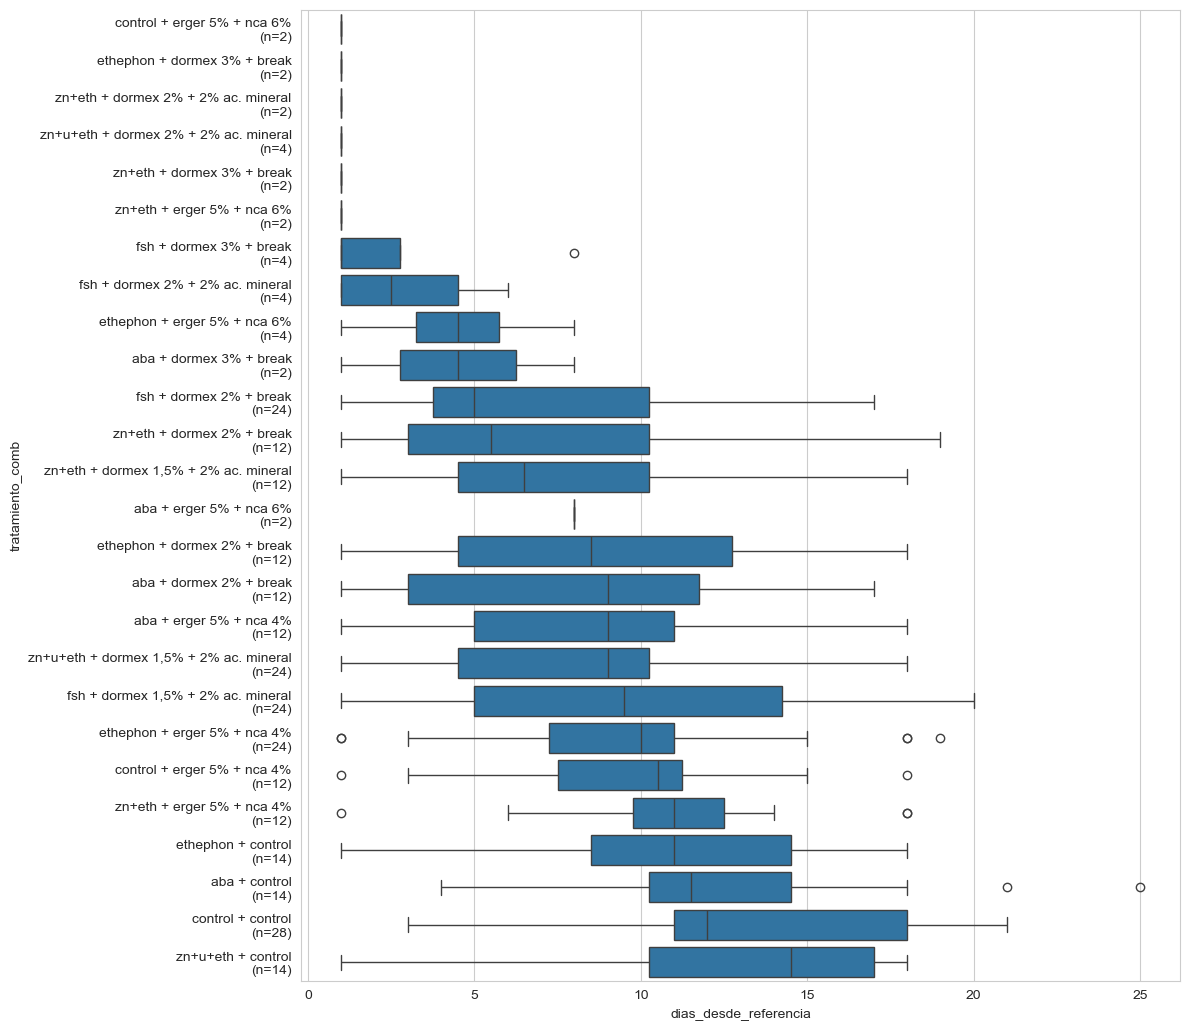

In [67]:
# Preparar estadísticas y orden por mediana
salida_de_latencia_por_entidad_merged['tratamiento_comb'] = (
    salida_de_latencia_por_entidad_merged['tratamiento_entrada'] + " + " +
    salida_de_latencia_por_entidad_merged['tratamiento_salida']
)
grp = salida_de_latencia_por_entidad_merged.groupby('tratamiento_comb')['dias_desde_referencia']
stats = grp.agg(['median', 'count']).sort_values('median')
order = stats.index.tolist()

# Tamaño dinámico
n = len(order)
figsize = (12, max(6, 0.4 * n))

plt.figure(figsize=figsize)
sns.set_style("whitegrid")

ax = sns.boxplot(
    x='dias_desde_referencia',
    y='tratamiento_comb',
    data=salida_de_latencia_por_entidad_merged,
    order=order,
    orient='h'
)

ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([f"{idx}\n(n={int(stats.loc[idx,'count'])})" for idx in order])
plt.tight_layout()
plt.show()

#### Genera tabla de salida de latencia

In [68]:
salida_de_latencia_por_entidad.to_csv('salida_de_latencia_por_entidad.csv', index=False)

#### Resumen

- Esta informacion es muy importante porque nos ayuda a definir el final del periodo de latencia. Se uso un ajuste lineal para estimar la fecha exacta en que cada entidad cruzo el umbral del 50% de brotacion en campo pero no se hizo un ajuste hacia el pasado ya que la función no es lineal y seria inducir un error.
- Se observa una variacion significativa en la fecha de salida de latencia entre diferentes zonas, tratamientos y variedades. Esta variable distribuye de manera diferente a la fecha de entrada a latencia, lo que sugiere que diferentes factores pueden influir en la duración del periodo de latencia. Esto es lo que esperabamos, sabemos que variables como la variedad y el tratamiento afectan la duracion de la latencia.
- Se genero una tabla de reporte con la entidad_id y la fecha estimada de salida de latencia para cada entidad. Esto es util para poder generar el dataset final.
- Se podria profundizar en como interpolar la fecha de salida de latencia, pero dado que la funcion no es lineal y no se tiene mucha informacion antes del cruce del umbral, se dejo como esta por ahora.
- Otra variable que podriamos ver es la cantidad de yemas como un indicador de vigor de la planta, pero por ahora no se incluyo en el analisis. Esto lo veremos con la tabla de cuaja ya que esa nos indica productividad del arbol. (Cuanta fruta termina dando)
- Descartamos un tercio de los datos debido a que no tenian datos de brotacion en campo, lo que es un porcentaje alto.

### Salida Cuaja

In [69]:
out_cuaja.head()

,entidad_id,momento,fecha_flores,fecha_frutos,numero_dardos,numero_flores,numero_frutos,porcentaje_cuaja
0,60,M2,2024-09-12,2024-11-04,3,5,1.0,20.000000
1,60,M2,2024-09-12,2024-11-04,2,21,3.0,14.285714
2,60,M2,2024-09-12,2024-11-04,1,39,2.0,5.128205
3,60,M2,2024-09-12,2024-11-04,4,17,3.0,17.647059
4,61,M2,2024-09-12,2024-11-04,9,14,1.0,7.142857


In [70]:
# Veamos que porcentaje de entidades tienen datos de cuaja
entidades_con_cuaja = out_cuaja['entidad_id'].unique().tolist()
entidades_sin_cuaja = list(set(entidades_unicas) - set(entidades_con_cuaja))
porcentaje_con_cuaja = (len(entidades_con_cuaja) / len(entidades_unicas)) * 100
porcentaje_sin_cuaja = (len(entidades_sin_cuaja) / len(entidades_unicas)) * 100
print(f"Porcentaje de entidades con datos de cuaja: {porcentaje_con_cuaja:.2f}%")
print(f"Porcentaje de entidades sin datos de cuaja: {porcentaje_sin_cuaja:.2f}%")

Porcentaje de entidades con datos de cuaja: 66.43%
Porcentaje de entidades sin datos de cuaja: 33.57%


In [71]:
# Conteo de mediciones por muestra
out_cuaja.groupby(['entidad_id', 'momento']).size().reset_index(name='count')

,entidad_id,momento,count
0,0,M2,4
1,0,M3,4
2,1,M2,4
3,1,M3,4
4,2,M2,3
...,...,...,...
327,405,M2,4
328,406,M2,4
329,407,M2,4
330,408,M2,4


In [72]:
# Agrupemos por entidad y momento
out_cuaja_grouped = out_cuaja.groupby(['entidad_id', 'momento']).agg({
    'fecha_flores': 'max',
    'fecha_frutos': 'max',
    'numero_flores': 'sum',
    'numero_frutos': 'sum',
}).reset_index()
out_cuaja_grouped['porcentaje_cuaja'] = out_cuaja_grouped['numero_frutos'] / out_cuaja_grouped['numero_flores']
out_cuaja_grouped

,entidad_id,momento,fecha_flores,fecha_frutos,numero_flores,numero_frutos,porcentaje_cuaja
0,0,M2,2024-09-16,2024-10-29,45,20.0,0.444444
1,0,M3,2024-10-01,2024-11-14,45,20.0,0.444444
2,1,M2,2024-09-16,2024-10-29,40,17.0,0.425000
3,1,M3,2024-10-01,2024-11-14,40,17.0,0.425000
4,2,M2,2024-09-16,2024-10-29,51,17.0,0.333333
...,...,...,...,...,...,...,...
327,405,M2,2024-10-02,2024-11-19,57,5.0,0.087719
328,406,M2,2024-10-02,2024-11-19,57,13.0,0.228070
329,407,M2,2024-10-02,2024-11-19,50,9.0,0.180000
330,408,M2,2024-10-02,2024-11-19,65,10.0,0.153846


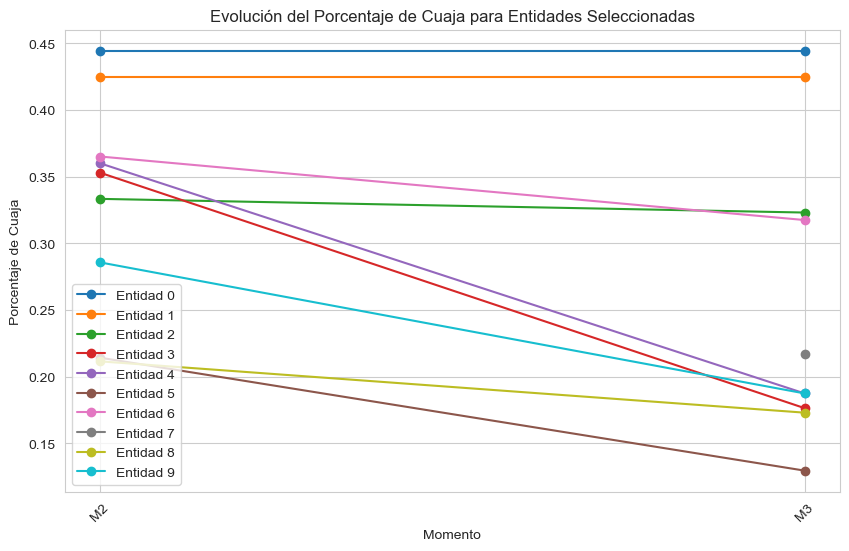

In [73]:
# Veamos la progresion del porcentaje de cuaja para algunas entidades
sampled_entities = out_cuaja_grouped['entidad_id'].unique()[:10]  # Tomemos las primeras 10 entidades como muestra
plt.figure(figsize=(10,6))
for entidad in sampled_entities:
    data_entidad = out_cuaja_grouped[out_cuaja_grouped['entidad_id'] == entidad]
    data_entidad = data_entidad.sort_values(by='momento')
    plt.plot(data_entidad['momento'], data_entidad['porcentaje_cuaja'], marker='o', label=f'Entidad {entidad}')
# Tilt the x-axis labels for
plt.xticks(rotation=45)
# Add legend
plt.legend()
plt.title('Evolución del Porcentaje de Cuaja para Entidades Seleccionadas')
plt.xlabel('Momento')
plt.ylabel('Porcentaje de Cuaja')
plt.show()

In [74]:
# Veamos la distribucion de la cantidad de dias entre flores y frutos
out_cuaja_grouped['fecha_flores'] = pd.to_datetime(out_cuaja_grouped['fecha_flores'])
out_cuaja_grouped['fecha_frutos'] = pd.to_datetime(out_cuaja_grouped['fecha_frutos'])
out_cuaja_grouped['dias_entre_flores_y_frutos'] = (out_cuaja_grouped['fecha_frutos'] - out_cuaja_grouped['fecha_flores']).dt.days
out_cuaja_grouped['dias_entre_flores_y_frutos'].describe()

count    332.000000
mean      59.343373
std       13.771644
min       42.000000
25%       44.000000
50%       53.000000
75%       72.000000
max       75.000000
Name: dias_entre_flores_y_frutos, dtype: float64

#### Genera tabla de cuaja por entidad y momento

In [75]:
out_cuaja_grouped.to_csv('out_cuaja_consolidado.csv', index=False)

#### Resumen

- Esta tabla habla de la productividad efectiva del cerezo. Entidades que no logran cuajar bien pueden tener problemas de vigor o salud. Esto se correlaciona con la latencia, plantas con mal reposo invernal se espera tengan peor cuaja o una cuaja desincronizada.
- Volvemos a perder 1/3 de las entidades por falta de datos.
- Se deja una tabla de reporte de cuaja consolidada por entidad y momento.
- Esta variables se podrian explotar en la segunda fase del proyecto cuando queramos cruzar la calidad de la cuaja con la fecha de la salida de la latencia.

## Exploracion Reportes

### Distribucion de la duracion de la latencia

In [76]:
latencia_por_entidad = pd.merge(
    entrada_a_latencia_por_entidad,
    salida_de_latencia_por_entidad,
    on='entidad_id',
    how='inner',
    validate='one_to_one',
    indicator=True
)
if (latencia_por_entidad['_merge'] != 'both').sum() > 0:
    print("Fallaron uniones (deberia ser 0):", (latencia_por_entidad['_merge'] != 'both').sum())
    raise ValueError("Fallo la union entre entrada_a_latencia_por_entidad y salida_de_latencia_por_entidad")
latencia_por_entidad.drop(columns=['_merge'], inplace=True)
latencia_por_entidad.head()

,entidad_id,fecha_entrada_latencia,fecha_salida_latencia
0,0,2024-05-08,2024-09-02
1,1,2024-05-12,2024-09-02
2,2,2024-05-15,2024-09-02
3,3,2024-05-05,2024-09-03
4,4,2024-05-12,2024-09-09


In [77]:
latencia_por_entidad['fecha_entrada_latencia'] = pd.to_datetime(latencia_por_entidad['fecha_entrada_latencia'])
latencia_por_entidad['fecha_salida_latencia'] = pd.to_datetime(latencia_por_entidad['fecha_salida_latencia'])
latencia_por_entidad['duracion_latencia_dias'] = (latencia_por_entidad['fecha_salida_latencia'] - latencia_por_entidad['fecha_entrada_latencia']).dt.days
latencia_por_entidad['duracion_latencia_dias'].describe()

count    279.000000
mean     121.376344
std        6.616277
min       96.000000
25%      117.000000
50%      121.000000
75%      126.000000
max      141.000000
Name: duracion_latencia_dias, dtype: float64

In [78]:
# Vamos a repetir los boxplots de duracion de latencia por zona, variedad y tratamiento
latencia_por_entidad_merged = latencia_por_entidad.merge(maestro_entidades, on='entidad_id', how='left', validate='many_to_one', indicator=True)
latencia_por_entidad_merged.head()

,entidad_id,fecha_entrada_latencia,fecha_salida_latencia,duracion_latencia_dias,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
0,0,2024-05-08,2024-09-02,117.0,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1,both
1,1,2024-05-12,2024-09-02,113.0,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2,both
2,2,2024-05-15,2024-09-02,110.0,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3,both
3,3,2024-05-05,2024-09-03,121.0,2,pichidegua,1,santina,3,zn+u+eth,6,control,4,both
4,4,2024-05-12,2024-09-09,120.0,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5,both


In [79]:
def quick_seaborn_boxplot(data, group_col, target_col):
    grp = data.groupby(group_col)[target_col]
    stats = grp.agg(['median', 'count']).sort_values('median')
    order = stats.index.tolist()

    n = len(order)
    figsize = (12, max(6, 0.4 * n))

    plt.figure(figsize=figsize)
    sns.set_style("whitegrid")

    ax = sns.boxplot(
        x=target_col,
        y=group_col,
        data=data,
        order=order,
        orient='h'
    )
    ax.set_yticks(np.arange(len(order)))
    ax.set_yticklabels([f"{idx}\n(n={int(stats.loc[idx,'count'])})" for idx in order])
    plt.tight_layout()
    plt.show()

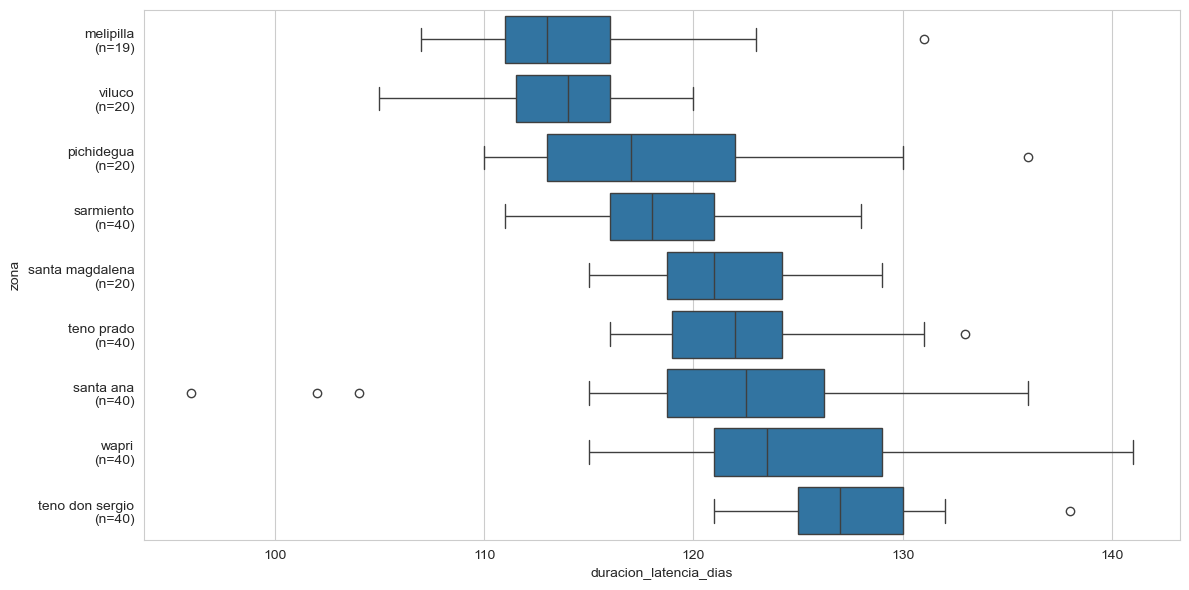

In [80]:
# Distribucion segun zona usando seaborn para hacer un boxplot horizontal ordenado por la media
# Preparar estadísticas y orden por mediana
quick_seaborn_boxplot(latencia_por_entidad_merged, 'zona', 'duracion_latencia_dias')


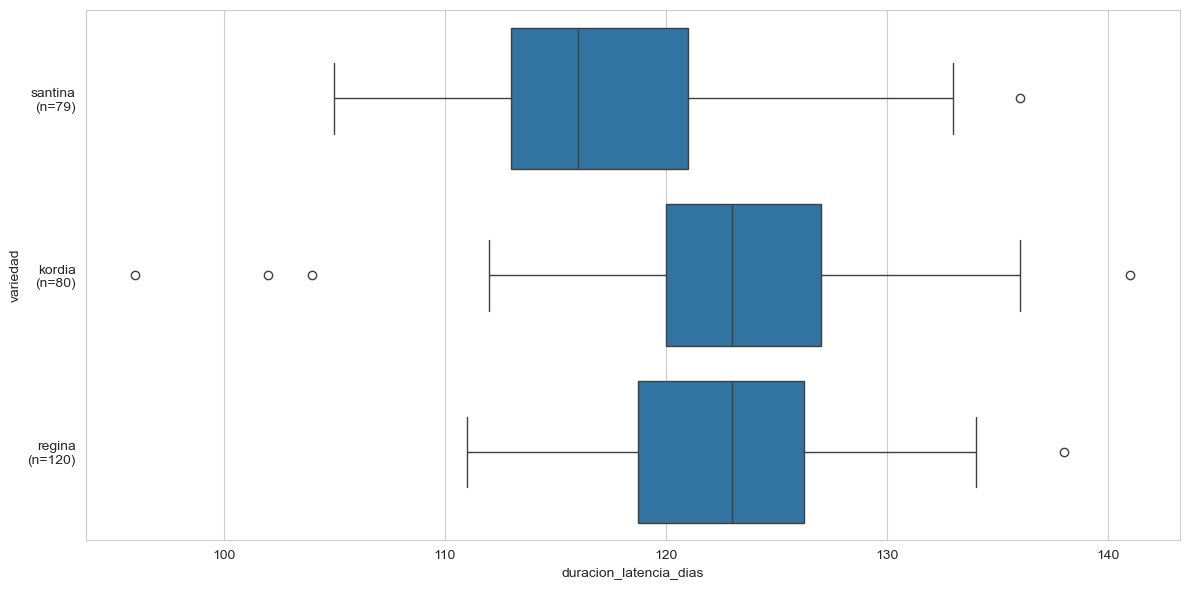

In [81]:
quick_seaborn_boxplot(latencia_por_entidad_merged, 'variedad', 'duracion_latencia_dias')

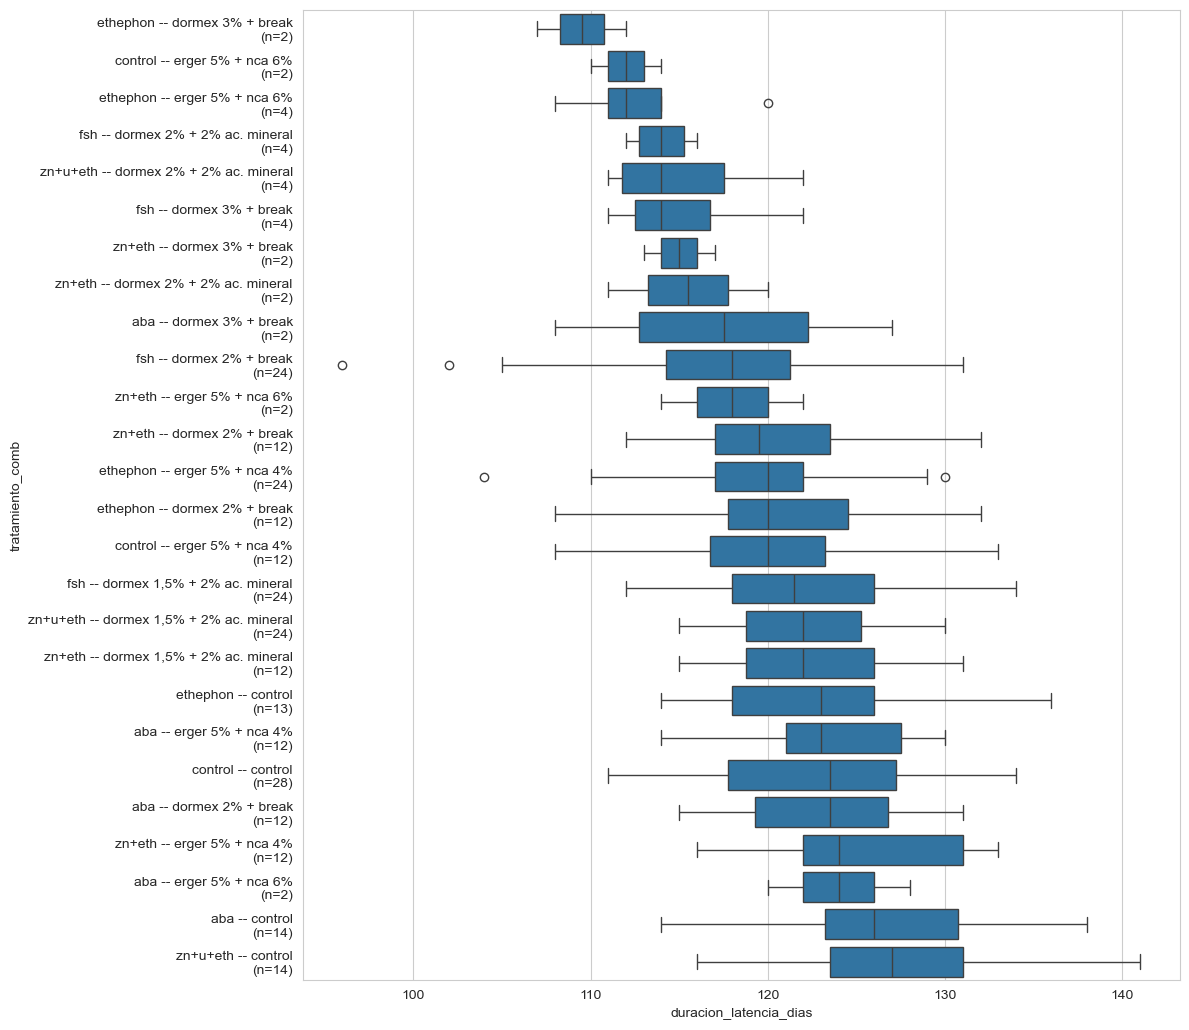

In [82]:
# Por combinacion de tratamiento de entrada y salida
latencia_por_entidad_merged['tratamiento_comb'] = latencia_por_entidad_merged['tratamiento_entrada'] + ' -- ' + latencia_por_entidad_merged['tratamiento_salida']
quick_seaborn_boxplot(latencia_por_entidad_merged, 'tratamiento_comb', 'duracion_latencia_dias')

Distribucion de duracion de latencia para variedad santina:


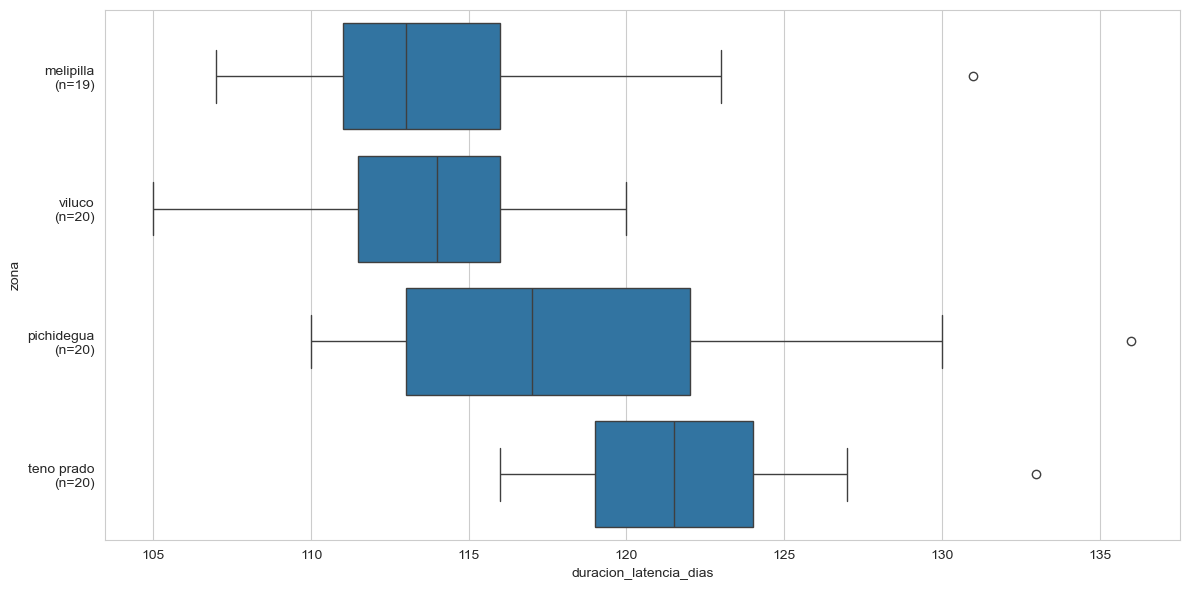

Distribucion de duracion de latencia para variedad kordia:


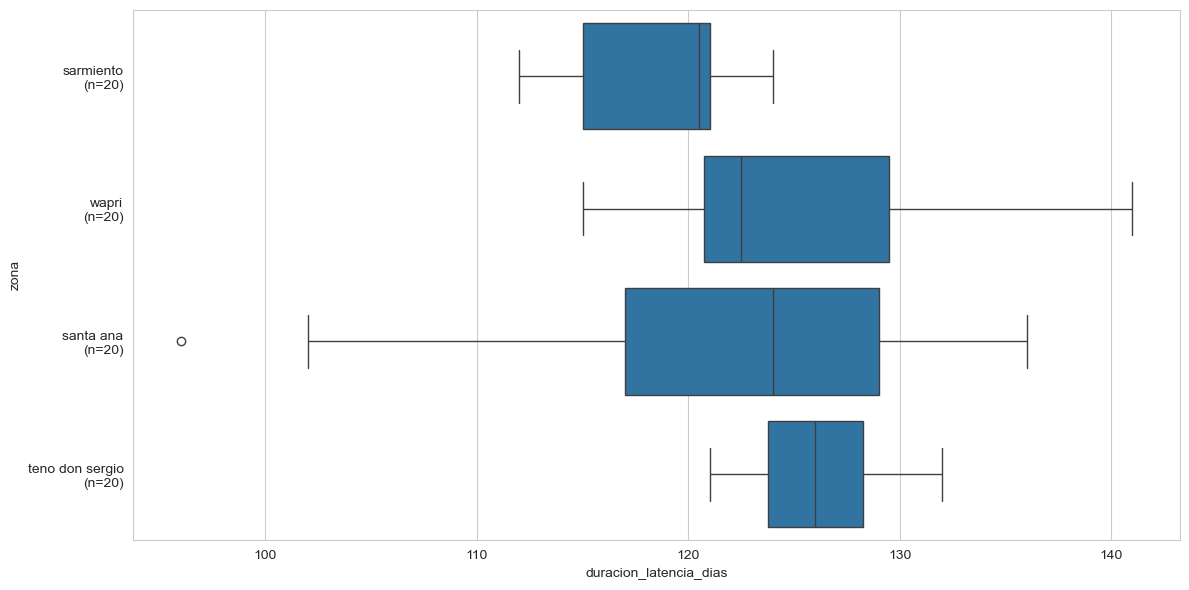

Distribucion de duracion de latencia para variedad regina:


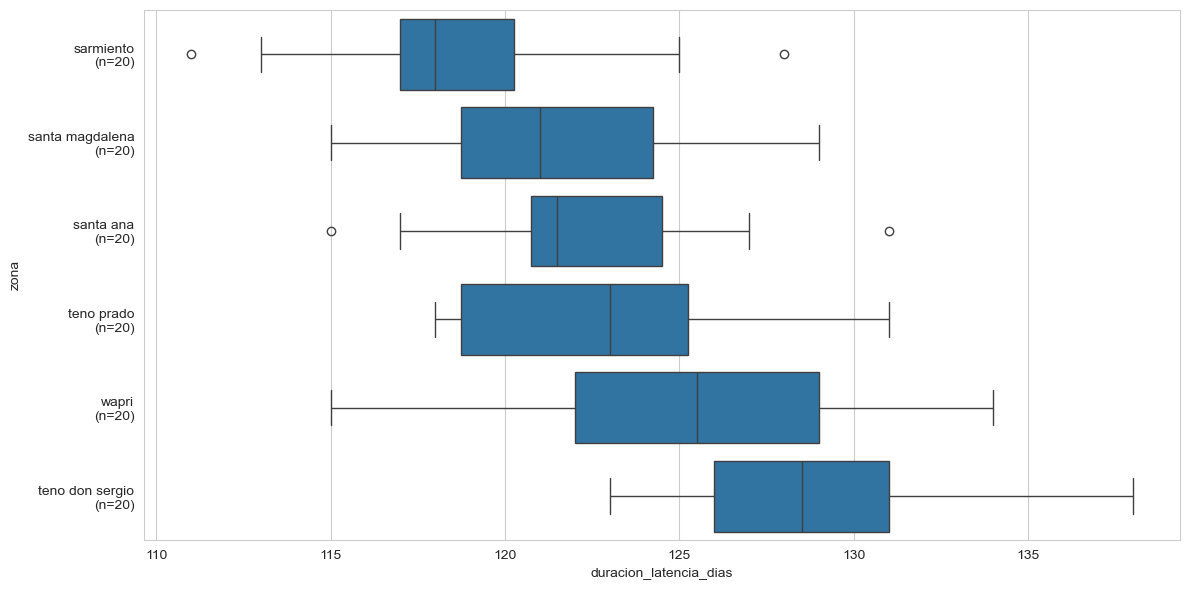

In [83]:
# Por variedad y zona
# Tres graficos pero filtrando primero por variedad
for variedad in latencia_por_entidad_merged['variedad'].unique():
    data_variedad = latencia_por_entidad_merged[latencia_por_entidad_merged['variedad'] == variedad]
    print(f"Distribucion de duracion de latencia para variedad {variedad}:")
    quick_seaborn_boxplot(data_variedad, 'zona', 'duracion_latencia_dias')

#### Resumen
- La duracion de la latencia varía significativamente entre diferentes zonas, variedades y tratamientos.
- Tiene mucho sentido usar esta variable como objetivo, pero haria el paso intermedio de contabilizar las horas frio acumuladas entre la entrada y salida de latencia para cada entidad, ya que es una variable mas robusta y menos dependiente de fechas exactas.
- Con esta información el problema se transformaria en la prediccion del requerimiento de horas frio para cada entidad a partir de sus caracteristicas, datos de entrada y datos de salida predecible.

### Conteo de horas frio por zona

In [84]:
def corte_simple(temp):
        return 1.0 if temp < 7 else 0.0

def aporte_frio_uta(temp):
    if 1 <= temp < 7:
        return 1.0
    elif 7 <= temp < 12:
        return 0.5
    elif temp >= 16:
        return -0.5
    else:
        return 0.0

def chill_from_range(df_temp, fecha_inicio, fecha_fin, fn):
    """
    df_temp: DataFrame con ['fecha_datetime', 'temperatura']
    fecha_inicio, fecha_fin: Timestamps
    """

    df = df_temp.sort_values("fecha_datetime")

    # Cortes
    total_range = fecha_fin - fecha_inicio
    f25 = fecha_inicio + total_range * 0.25
    f50 = fecha_inicio + total_range * 0.50
    f75 = fecha_inicio + total_range * 0.75

    def chill_until(fecha_corte):
        sub = df[(df["fecha_datetime"] >= fecha_inicio) &
                 (df["fecha_datetime"] <= fecha_corte)]
        return (sub["temperatura"].apply(fn)).sum()


    return {
        "chill_25": chill_until(f25),
        "chill_50": chill_until(f50),
        "chill_75": chill_until(f75),
        "chill_100": chill_until(fecha_fin)
    }


In [85]:
df_temperaturas = {}
df_temperaturas[0] = pd.read_csv(temp_zone_1_path)
df_temperaturas[1] = pd.read_csv(temp_zone_2_path)
df_temperaturas[2] = pd.read_csv(temp_zone_3_path)
df_temperaturas[3] = pd.read_csv(temp_zone_4_path)
df_temperaturas[4] = pd.read_csv(temp_zone_5_path)
df_temperaturas[5] = pd.read_csv(temp_zone_6_path)
df_temperaturas[6] = pd.read_csv(temp_zone_7_path)
df_temperaturas[7] = pd.read_csv(temp_zone_8_path)
df_temperaturas[8] = pd.read_csv(temp_zone_9_path)

# Casteamos a datetime la columna de fecha
for zone, df in df_temperaturas.items():
    df['fecha_datetime'] = pd.to_datetime(df['fecha_datetime'])


In [86]:
maestros_zonas

,zona_id,zona
0,0,melipilla
1,1,viluco
2,2,pichidegua
3,3,teno prado
4,4,santa ana
5,5,teno don sergio
6,6,sarmiento
7,7,wapri
8,8,santa magdalena


### Generacion de dataset

In [87]:
in_materia_seca_merged_clean

,entidad_id,fecha,muestreo,peso_fresco,peso_seco,porcentaje_humedad,zona_id,zona,variedad_id,variedad,tratamiento_entrada_id,tratamiento_entrada,tratamiento_salida_id,tratamiento_salida,ue,_merge
0,0,2024-04-19,M1,0.4124,0.2157,52.303589,2,pichidegua,1,santina,2,zn+eth,7,dormex 3% + break,1,both
1,1,2024-04-19,M1,0.3628,0.1819,50.137817,2,pichidegua,1,santina,1,fsh,8,dormex 2% + 2% ac. mineral,2,both
2,2,2024-04-19,M1,0.3180,0.1591,50.031447,2,pichidegua,1,santina,0,control,11,erger 5% + nca 6%,3,both
3,3,2024-04-19,M1,0.5819,0.2839,48.788452,2,pichidegua,1,santina,3,zn+u+eth,6,control,4,both
4,4,2024-04-19,M1,0.3340,0.1667,49.910180,2,pichidegua,1,santina,4,ethephon,11,erger 5% + nca 6%,5,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1674,414,2024-07-01,M4,0.6551,0.2938,44.848115,7,wapri,2,kordia,3,zn+u+eth,13,NaN,25,both
1675,415,2024-07-01,M4,0.7273,0.2918,40.120995,7,wapri,2,kordia,4,ethephon,13,NaN,26,both
1677,417,2024-07-01,M4,0.4691,0.1539,32.807504,7,wapri,2,kordia,2,zn+eth,13,NaN,28,both
1678,418,2024-07-01,M4,0.5035,0.2129,42.284012,7,wapri,2,kordia,1,fsh,13,NaN,29,both


In [88]:
# Vamos a juntar la latencia con el almidon en yema y los pesos de materia seca
dataset_final = latencia_por_entidad.merge(
    in_almidon_merged[['entidad_id', 'absorbancia', 'concentracion_almidon_mg_por_g', 'peso_yema_mg']].loc[in_almidon_merged['muestreo']=='M1'],
    on='entidad_id',
    how='left',
    validate='one_to_one',
    indicator=True
)
dataset_final.drop(columns=['_merge'], inplace=True)
dataset_final = dataset_final.merge(
    in_materia_seca_merged_clean[['entidad_id', 'muestreo', 'peso_fresco', 'peso_seco', 'porcentaje_humedad']].loc[in_materia_seca_merged_clean['muestreo']=='M1'],
    on='entidad_id',
    how='left',
    validate='one_to_one',
    indicator=True
)
dataset_final.drop(columns=['_merge'], inplace=True)
# Añadimos la informacion de maestro de entidades
dataset_final = dataset_final.merge(
    maestro_entidades,
    on='entidad_id',
    how='left',
    validate='one_to_one',
    indicator=True
)
dataset_final.drop(columns=['_merge'], inplace=True)
# Drop if duracion_latencia_dias is null
dataset_final = dataset_final.dropna(subset=['duracion_latencia_dias'])
dataset_no_final = dataset_final.copy()

In [89]:
dataset_final.to_csv("dataset_crudo.csv")

In [90]:
# Añadamos las columnas de horas frio acumuladas en distintos percentiles de la latencia por zona_id
fecha_inicio, fecha_fin = pd.to_datetime('2024-05-01'), pd.to_datetime('2024-10-01')
for zona_id in dataset_final['zona_id']:
    df_temp = df_temperaturas[zona_id]
    chill_counts = chill_from_range(df_temp, pd.to_datetime(fecha_inicio), pd.to_datetime(fecha_fin), aporte_frio_uta)
    chill_counts_basic = chill_from_range(df_temp, pd.to_datetime(fecha_inicio), pd.to_datetime(fecha_fin), corte_simple)
    for key, value in chill_counts.items():
        dataset_final.loc[dataset_final['zona_id'] == zona_id, key+'_uta'] = value
    for key, value in chill_counts_basic.items():
        dataset_final.loc[dataset_final['zona_id'] == zona_id, key+'_simple'] = value


In [88]:
dataset_final.head()

,entidad_id,fecha_entrada_latencia,fecha_salida_latencia,duracion_latencia_dias,absorbancia,concentracion_almidon_mg_por_g,peso_yema_mg,muestreo,peso_fresco,peso_seco,...,tratamiento_salida,ue,chill_25_uta,chill_50_uta,chill_75_uta,chill_100_uta,chill_25_simple,chill_50_simple,chill_75_simple,chill_100_simple
0,0,2024-05-08,2024-09-02,117.0,NaN,NaN,NaN,M1,0.4124,0.2157,...,dormex 3% + break,1,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
1,1,2024-05-12,2024-09-02,113.0,NaN,NaN,NaN,M1,0.3628,0.1819,...,dormex 2% + 2% ac. mineral,2,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
2,2,2024-05-15,2024-09-02,110.0,NaN,NaN,NaN,M1,0.3180,0.1591,...,erger 5% + nca 6%,3,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
3,3,2024-05-05,2024-09-03,121.0,NaN,NaN,NaN,M1,0.5819,0.2839,...,control,4,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
4,4,2024-05-12,2024-09-09,120.0,NaN,NaN,NaN,M1,0.3340,0.1667,...,erger 5% + nca 6%,5,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0


In [89]:
for x in dataset_final.columns:
    print(x)

entidad_id
fecha_entrada_latencia
fecha_salida_latencia
duracion_latencia_dias
absorbancia
concentracion_almidon_mg_por_g
peso_yema_mg
muestreo
peso_fresco
peso_seco
porcentaje_humedad
zona_id
zona
variedad_id
variedad
tratamiento_entrada_id
tratamiento_entrada
tratamiento_salida_id
tratamiento_salida
ue
chill_25_uta
chill_50_uta
chill_75_uta
chill_100_uta
chill_25_simple
chill_50_simple
chill_75_simple
chill_100_simple


In [90]:
dataset_final = dataset_final.drop(columns=['muestreo', 'fecha_entrada_latencia', 'fecha_salida_latencia', 'zona', 'variedad', 'tratamiento_entrada', 'tratamiento_salida', 'ue', 'entidad_id' ])
dataset_final.to_csv('dataset_dias_latencia.csv', index=False)
dataset_final

,duracion_latencia_dias,absorbancia,concentracion_almidon_mg_por_g,peso_yema_mg,peso_fresco,peso_seco,porcentaje_humedad,zona_id,variedad_id,tratamiento_entrada_id,tratamiento_salida_id,chill_25_uta,chill_50_uta,chill_75_uta,chill_100_uta,chill_25_simple,chill_50_simple,chill_75_simple,chill_100_simple
0,117.0,NaN,NaN,NaN,0.4124,0.2157,52.303589,2,1,2,7,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
1,113.0,NaN,NaN,NaN,0.3628,0.1819,50.137817,2,1,1,8,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
2,110.0,NaN,NaN,NaN,0.3180,0.1591,50.031447,2,1,0,11,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
3,121.0,NaN,NaN,NaN,0.5819,0.2839,48.788452,2,1,3,6,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
4,120.0,NaN,NaN,NaN,0.3340,0.1667,49.910180,2,1,4,11,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,134.0,1.0292,22.085770,200.3,0.4483,0.2102,46.888244,7,2,0,6,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
276,136.0,0.9343,19.923664,200.0,0.7321,0.3450,47.124710,7,2,4,6,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
277,118.0,1.0393,22.330203,200.2,0.6290,0.2973,47.265501,7,2,2,16,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
278,115.0,0.9611,20.482158,200.6,0.4514,0.2159,47.828977,7,2,4,12,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0


In [91]:
len(dataset_final.dropna())

96

In [92]:
#Select rows where any of the columns is NaN
nan_rows = dataset_final[dataset_final.isnull().any(axis=1)]
nan_rows

,duracion_latencia_dias,absorbancia,concentracion_almidon_mg_por_g,peso_yema_mg,peso_fresco,peso_seco,porcentaje_humedad,zona_id,variedad_id,tratamiento_entrada_id,tratamiento_salida_id,chill_25_uta,chill_50_uta,chill_75_uta,chill_100_uta,chill_25_simple,chill_50_simple,chill_75_simple,chill_100_simple
0,117.0,NaN,NaN,NaN,0.4124,0.2157,52.303589,2,1,2,7,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
1,113.0,NaN,NaN,NaN,0.3628,0.1819,50.137817,2,1,1,8,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
2,110.0,NaN,NaN,NaN,0.3180,0.1591,50.031447,2,1,0,11,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
3,121.0,NaN,NaN,NaN,0.5819,0.2839,48.788452,2,1,3,6,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
4,120.0,NaN,NaN,NaN,0.3340,0.1667,49.910180,2,1,4,11,400.0,836.0,1236.0,1421.0,334.0,717.0,998.0,1180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,127.0,NaN,NaN,NaN,0.6115,0.2913,47.636958,7,2,0,6,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
268,122.0,NaN,NaN,NaN,0.8050,0.3854,47.875776,7,2,1,16,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
269,124.0,NaN,NaN,NaN,0.3538,0.1711,48.360656,7,2,5,6,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0
270,121.0,NaN,NaN,NaN,0.4381,0.2092,47.751655,7,2,2,12,459.5,867.5,1354.0,1671.0,388.0,850.0,1274.0,1532.0


### Conteo de horas frio en latencia

In [ ]:
def chill_from_latencia(row, df_temp, fn):
    fecha_inicio = pd.to_datetime(row['fecha_entrada_latencia'])
    fecha_fin = pd.to_datetime(row['fecha_salida_latencia'])
    return chill_from_range(df_temp, fecha_inicio, fecha_fin, fn)

In [194]:
for index, row in dataset_no_final.iterrows():
    zona_id = row['zona_id']
    df_temp = df_temperaturas[zona_id]
    chill_counts = chill_from_latencia(row, df_temp, corte_simple)
    # Tomamos solo las horas frias acumuladas al 100
    dataset_no_final.at[index, 'frio_acumulado'] = chill_counts['chill_100']

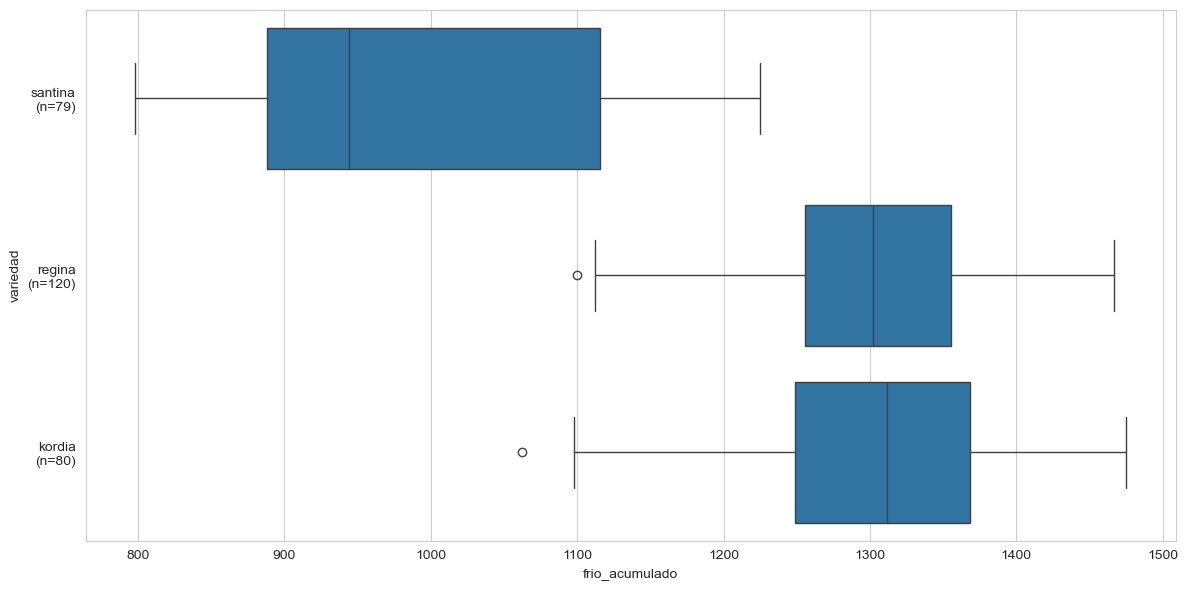

In [195]:
# Grafiquemos la distribucion de frio acumulado por variedad y zona
quick_seaborn_boxplot(dataset_no_final, 'variedad', 'frio_acumulado')

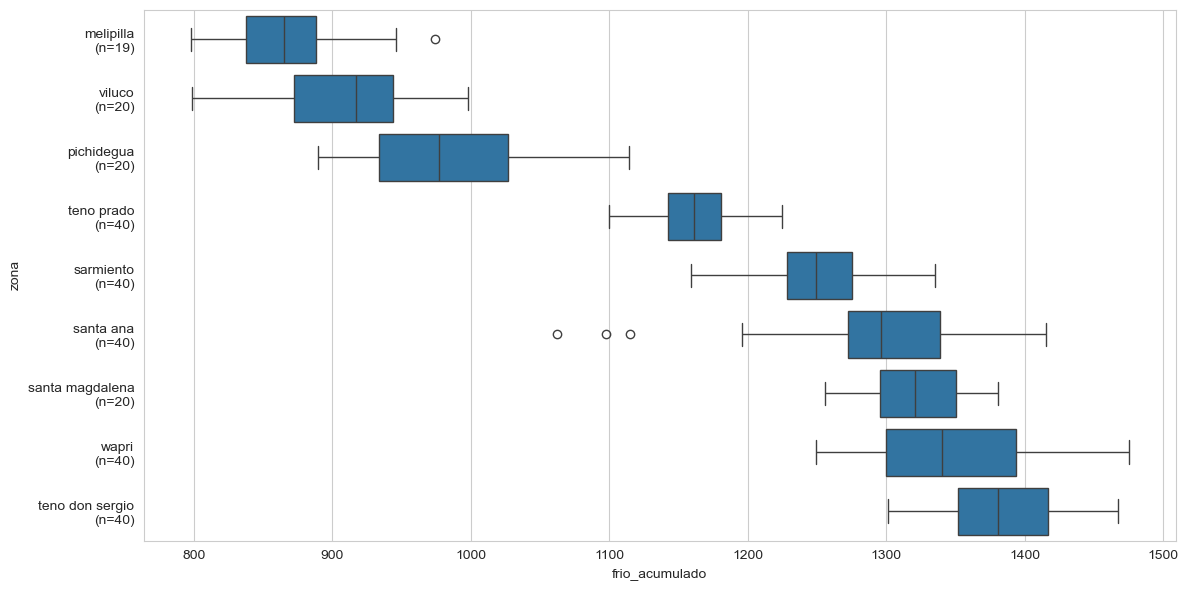

In [196]:
# Por zona
quick_seaborn_boxplot(dataset_no_final, 'zona', 'frio_acumulado')

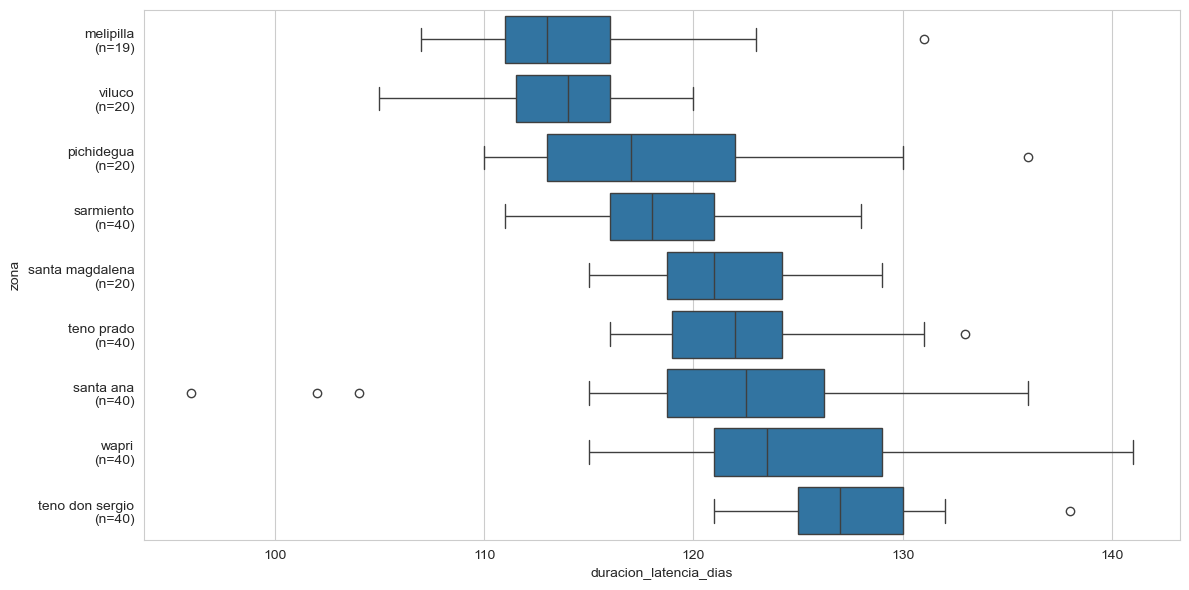

In [197]:
# Dias en la tencia por zona
quick_seaborn_boxplot(dataset_no_final, 'zona', 'duracion_latencia_dias')

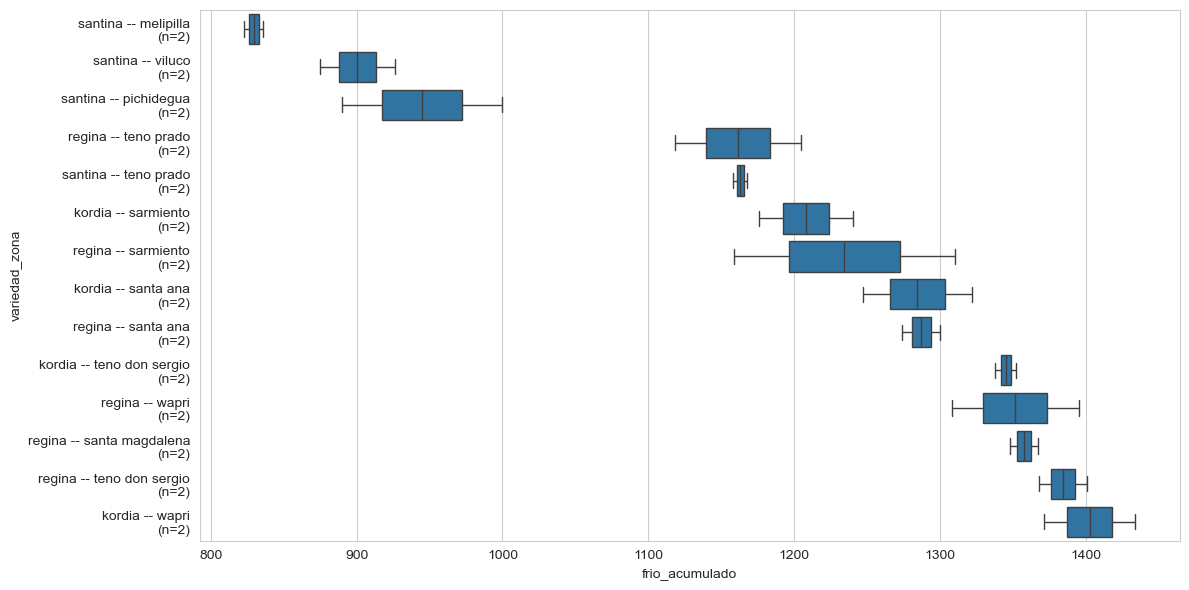

In [198]:
dataset_no_final['variedad_zona'] = dataset_no_final['variedad'] + ' -- ' + dataset_no_final['zona']
quick_seaborn_boxplot(dataset_no_final.loc[dataset_no_final['tratamiento_entrada']=='control'].loc[dataset_no_final['tratamiento_salida']=='control'], 'variedad_zona', 'frio_acumulado')

In [199]:
dataset_no_final.columns

Index(['entidad_id', 'fecha_entrada_latencia', 'fecha_salida_latencia',
       'duracion_latencia_dias', 'absorbancia',
       'concentracion_almidon_mg_por_g', 'peso_yema_mg', 'muestreo',
       'peso_fresco', 'peso_seco', 'porcentaje_humedad', 'zona_id', 'zona',
       'variedad_id', 'variedad', 'tratamiento_entrada_id',
       'tratamiento_entrada', 'tratamiento_salida_id', 'tratamiento_salida',
       'ue', 'frio_acumulado', 'variedad_zona'],
      dtype='object')

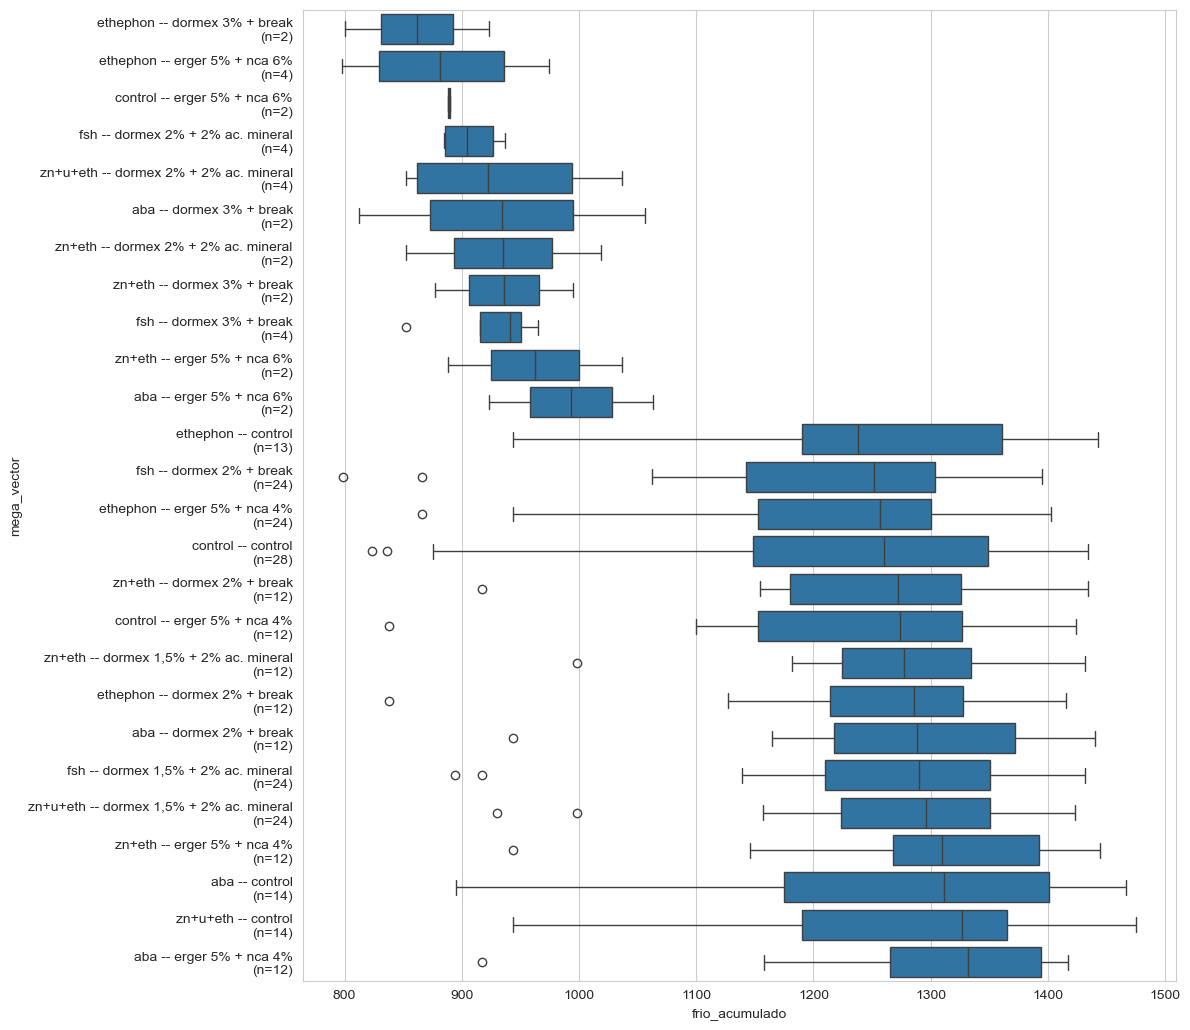

In [200]:
dataset_no_final['mega_vector'] = dataset_no_final['tratamiento_entrada'] + ' -- ' + dataset_no_final['tratamiento_salida']
quick_seaborn_boxplot(dataset_no_final, 'mega_vector', 'frio_acumulado')